# 딥러닝심화 과제 8 - 기말 과제
## Consistency Models를 활용한 반도체 웨이퍼 결함 패턴 생성
#### 컴퓨터공학부 인공지능공학과 20231049 정우제
#### 2025.12.22
<hr>

1. [서론](#1-서론)
2. [Consistency Models 이론](#2-consistency-models-이론)
3. [데이터셋 소개 및 학습설정](#3-데이터셋-소개-및-학습설정)
4. [DDPM 및 DDIM 구현](#4-DDPM-및-DDIM-구현)
5. [Consistency Models 구현](#5-consistency-models-구현)
6. [실험 결과 및 종합분석](#6-실험-결과-및-종합분석)
7. [참고문헌](#7-참고문헌)

### 1. 서론
### 1.1 연구 배경 및 동기

#### 1.1.1 생성 모델의 발전: GAN에서 Diffusion으로

최근 몇 년간 생성 모델(Generative Models)은 GAN(Generative Adversarial Networks)에서 Diffusion Models로 패러다임이 전환되었다. 

**GAN의 한계**
* **Mode Collapse**: 생성 모델이 데이터 분포의 일부만 학습하여 다양성이 떨어지는 문제
* **불안정한 학습**: Generator와 Discriminator 간의 균형을 맞추기 어려움
* **까다로운 하이퍼파라미터 튜닝**: 학습이 매우 민감하여 재현성 확보 어려움

**Diffusion Models의 장점**
* **안정적인 학습**: Adversarial 학습 없이 단순한 denoising 목표
* **우수한 샘플 품질**: 현재 SOTA 이미지 생성 성능
* **아키텍처 유연성**: Autoregressive Model과 달리 다양한 데이터 모달리티에 쉽게 적용

<div align="center">
<img src="./HW08_img/diffusion.png" width="700">
<p><b>그림 1.</b> 생성모델들의 강점</p>
</div>

---

#### 1.1.2 Diffusion Models의 우수성과 한계



| 모델 | 장점 | 단점 |
|------|------|------|
| **GAN** | • 빠른 샘플링 속도<br>• 고해상도 생성 가능 | • 불안정한 학습<br>• Mode Collapse<br>• 까다로운 하이퍼파라미터 튜닝 |
| **VAE** | • 탄탄한 수학적 기반<br>• 안정적인 학습 | • 생성 결과물의 선명도 저하<br>• Blurry samples |
| **Diffusion** | • 최고 수준의 샘플 품질<br>• 안정적인 학습<br>• 다양한 모달리티 확장성 | • 매우 느린 샘플링 속도<br>• High Inference Cost (NFE=1000) |
                                                                **표 1. 주요 생성 모델 비교**

Diffusion Models는 우수한 성능에도 불구하고 생성 속도라는 치명적인 단점이 있다. 

---

### 1.2 Diffusion Models의 발전 과정

#### 1.2.1 DDPM (Denoising Diffusion Probabilistic Models)

DDPM은 2020년 Ho et al.에 의해 제안된 diffusion 기반 생성 모델로, 다음 두 가지 Markov chain으로 구성된다.

##### (1) Forward Process (확산 과정)

데이터 $x_0$에 점진적으로 가우시안 노이즈를 추가하는 과정이다.

$$q(x_t|x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

<div align="center">
<img src="./HW08_img/DDPM_forward.png" width="600">
<p><b>그림 2.</b> DDPM Forward Process: 데이터에 점진적으로 노이즈 추가</p>
</div>

주요 특징
* $\beta_t \in (0, 1)$: Noise schedule 파라미터 (일반적으로 증가하는 수열)
* 각 step마다 미세한 노이즈가 누적
* $t \to T$일 때 최종적으로 순수 가우시안 분포 $\mathcal{N}(0, I)$에 도달

Reparameterization Trick을 사용하면 임의의 timestep에서 직접 계산 가능

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

여기서 $\alpha_t = 1 - \beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$

---
##### (2) Reverse Process (역확산 과정)

노이즈 $x_T \sim \mathcal{N}(0, I)$에서 데이터 $x_0$를 복원하는 과정이다.

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

<div align="center">
<img src="./HW08_img/DDPM_reverse.png" width="600">
<p><b>그림 3.</b> DDPM Reverse Process: 노이즈에서 데이터 복원</p>
</div>

**핵심 가정**
* 각 step 간의 노이즈 변화가 매우 작아야 Gaussian 근사 유효
* 한 번에 큰 변화를 주면 근사가 깨짐
* **따라서 작은 step으로 천천히 노이즈를 제거해야 함**
---

##### (3) 학습 목표

DDPM의 학습은 **노이즈 예측 문제**로 단순화된다.

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

**알고리즘 1. DDPM Training**
```
1. x_0 ~ q(x_0) 데이터 샘플링
2. t ~ Uniform({1, ..., T}) 랜덤 timestep
3. ε ~ N(0, I) 가우시안 노이즈
4. x_t = √(ᾱ_t) x_0 + √(1-ᾱ_t) ε
5. Loss = ||ε - ε_θ(x_t, t)||² 최소화
```

**알고리즘 2. DDPM Sampling**
```
1. x_T ~ N(0, I) 순수 노이즈에서 시작
2. for t = T, T-1, ..., 1:
3.     ε_pred = ε_θ(x_t, t)
4.     x_(t-1) = μ_θ(x_t, t) + σ_t z  (z ~ N(0, I))
5. return x_0
```

---

##### (4) DDPM의 한계: NFE=1000의 속도 제약

**근본적인 문제**

> Gaussian 근사가 유효하려면 각 step의 변화량이 매우 작아야 한다.


* **T=1000 step 필요**: 1000번의 신경망 forward pass
* **느린 생성 속도**: 이미지 1장 생성에 수십 초 소요
* **실시간 응용 불가능**: 산업 현장, 대화형 시스템에 적용 어려움

**해결 방향**
* Step 수를 줄이면서도 품질을 유지하는 방법 필요
* 이를 위해 연속 시간 관점의 재해석 등장

---


#### 1.2.2 Score-SDE: 연속 시간 관점의 재해석

기존 DDPM의 discrete한 timestep을 **연속 시간 확률 미분방정식(SDE)**으로 확장하였다.

##### (1) Forward SDE

$$dx = f(x, t)dt + g(t)dw$$

* $f(x,t)$: **Drift term** - 데이터를 천천히 prior(0)로 수렴
* $g(t)$: **Diffusion coefficient** - 노이즈의 강도 조절
* $dw$: **Standard Wiener process** - 무작위 노이즈

**수학적 의미**
> 시간이 흐를수록 데이터 $x$가 drift $f$ 방향으로 이동하면서, 동시에 $g$만큼의 무작위 노이즈가 섞인다.

**DDPM과의 연결**
* Variance Preserving (VP) SDE 
  $$f(x,t) = -\frac{1}{2}\beta(t)x, \quad g(t) = \sqrt{\beta(t)}$$

---

##### (2) Reverse SDE

Forward SDE의 시간을 역전시킨 과정

$$dx = [f(x, t) - g(t)^2 \nabla_x \log p_t(x)] dt + g(t) d\bar{w}$$

**핵심 요소**
* $\nabla_x \log p_t(x)$: **Score Function**
  - 현재 노이즈 상태 $x_t$에서 **진짜 데이터 분포로 가는 방향**
  - Gradient of log probability
  
**생성 모델의 핵심 아이디어**
> "노이즈를 걷어내려면 어느 방향으로 가야 하는지를 학습한다"

* 신경망 $s_\theta(x, t)$가 Score Function을 근사: $s_\theta(x, t) \approx \nabla_x \log p_t(x)$
* Score matching 기법으로 학습

---

##### (3) Probability Flow ODE (PF-ODE)

Reverse SDE와 **동일한 marginal distribution** $p_t(x)$를 가지지만, **노이즈 항이 없는 결정론적 방정식**:

$$dx = \left[ f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x) \right] dt$$

**PF-ODE의 특징**

1. **Deterministic (결정론적)**
   * 랜덤 요소 제거
   * 같은 초기값 → 항상 같은 결과
   * 재현 가능성 확보

2. **Smooth Trajectory**
   * 부드러운 곡선을 따라 이동
   * 노이즈 → 데이터로 자연스러운 변환

3. **양방향 가능**
   * Forward (t=0 → T): 데이터 → 노이즈
   * Backward (t=T → 0): 노이즈 → 데이터
   * 동일한 ODE 사용

4. **Exact Likelihood 계산 가능**
   * Change of variables formula 적용
   * VAE처럼 likelihood 기반 학습 가능

<div align="center">
<img src="./HW08_img/sde.png" width="700">
<p><b>그림 4.</b> SDE vs ODE trajectory 비교</p>
</div>

**중요성**
* DDIM의 이론적 근거 제공
* **Consistency Models의 핵심 기반**
* 연속 시간 관점에서 diffusion 통합 이해

---

#### 1.2.3 DDIM (Denoising Diffusion Implicit Models)

DDIM은 DDPM의 forward process를 **non-Markovian**으로 재정의하여 샘플링 속도를 획기적으로 개선했다.

##### (1) Non-Markovian Forward Process

DDPM과 달리 $x_{t-1}$이 $x_t$뿐만 아니라 $x_0$에도 의존

$$q(x_{t-1}|x_t, x_0) = \mathcal{N}\left(x_{t-1}; \sqrt{\bar{\alpha}_{t-1}}x_0 + \sqrt{1-\bar{\alpha}_{t-1}-\sigma_t^2} \cdot \frac{x_t - \sqrt{\bar{\alpha}_t}x_0}{\sqrt{1-\bar{\alpha}_t}}, \sigma_t^2 I\right)$$

**핵심 파라미터** $\sigma_t$

* $\sigma_t = \sqrt{\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}} \sqrt{1-\frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}$ → DDPM (stochastic)
* $\sigma_t = 0$ → **DDIM (deterministic)**

---

##### (2) Deterministic Sampling과 가속화

$\sigma_t = 0$일 때 DDIM sampling

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \underbrace{\left( \frac{x_t - \sqrt{1-\bar{\alpha}_t} \epsilon_\theta(x_t, t)}{\sqrt{\bar{\alpha}_t}} \right)}_{\text{predicted } \hat{x}_0} + \sqrt{1-\bar{\alpha}_{t-1}} \epsilon_\theta(x_t, t)$$

**핵심 아이디어**
1. 현재 $x_t$에서 clean image $\hat{x}_0$ 예측
2. $\hat{x}_0$를 이용해 $x_{t-1}$ 직접 계산
3. **노이즈 항 없음** → Deterministic

**가속화 전략**

전체 timestep $\{1, 2, \ldots, 1000\}$ 대신 부분집합 $\{\tau_1, \tau_2, \ldots, \tau_S\}$ 사용:

$$x_{\tau_{i-1}} = \sqrt{\bar{\alpha}_{\tau_{i-1}}} \hat{x}_0 + \sqrt{1-\bar{\alpha}_{\tau_{i-1}}} \epsilon_\theta(x_{\tau_i}, \tau_i)$$

**알고리즘 3. DDIM Accelerated Sampling**
```
Input: ε_θ, subsequence τ = {τ_1, ..., τ_S}  (S << T)
1. x_T ~ N(0, I)
2. for i = S, S-1, ..., 1:
3.     ε_pred = ε_θ(x_τᵢ, τᵢ)
4.     x̂_0 = (x_τᵢ - √(1-ᾱ_τᵢ) ε_pred) / √(ᾱ_τᵢ)
5.     x_τᵢ₋₁ = √(ᾱ_τᵢ₋₁) x̂_0 + √(1-ᾱ_τᵢ₋₁) ε_pred
6. return x_0
```

**속도 향상**
* DDPM: T=1000 → NFE=1000
* DDIM: S=100 → NFE=100 (**10배 빠름**)
* DDIM: S=50 → NFE=50 (**20배 빠름**)

---

##### (3) DDIM의 성과와 한계

**표 2. DDPM vs DDIM 비교**

| 특징 | DDPM | DDIM |
|------|------|------|
| **Forward Process** | Markovian | Non-Markovian |
| **Sampling** | Stochastic | Deterministic |
| **NFE** | 1000 | 50-100 |
| **속도** | 느림 (1x) | 10-20배 빠름 |
| **품질** | 최고 | DDPM과 거의 동일 |
| **다양성** | 높음 | 낮음 (deterministic) |
| **재현성** | 어려움 | 쉬움 |

**DDIM의 성과**
* 10-20배 속도 향상
* 품질 유지
* Deterministic → 재현 가능

**여전한 한계**
* NFE=50-100 여전히 필요
* Real-time 응용에는 부족 (이미지 1장에 수 초)
* 산업 현장 적용 한계

## 2. Consistency Models 이론

### 2.1 Consistency Models의 핵심 아이디어

#### 2.1.1 배경: PF-ODE의 한계

**Probability Flow ODE (PF-ODE)**는 다음과 같은 중요한 특성을 보여주었다

$$dx = \left[ f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x) \right] dt$$

**PF-ODE의 의미**
* 노이즈 $x_T$에서 데이터 $x_\epsilon$로 가는 **결정론적 경로(trajectory)**가 존재
* 같은 초기 노이즈는 항상 같은 데이터로 매핑됨
* 부드럽고 연속적인 궤적을 따라 변환

<div align="center">
<img src="./HW08_img/consistency_methods.png" width="700">
<p><b>그림 5.</b> Consistency Models PF ODE</p>
</div>

**기존 방법의 문제점**

DDIM과 같은 기존 방법들은 이 PF-ODE를 수치적으로 풀어야했다
```
x_T → x_{T-Δt} → x_{T-2Δt} → ... → x_ε
 └─────┴─────────┴──────────────┴────> NFE=100~1000
```

* **반복적 연산**: ODE solver가 매 step마다 신경망 호출
* **누적 오차**: 각 step의 근사 오차가 누적
* **느린 속도**: NFE=50-100 필요

**Consistency Models**

> "PF-ODE 궤적의 **기하학적 특성**을 직접 학습하여, 반복 없이 **한 번에 시작점으로 점프**"
```
x_T ──────────────────────────────> x_ε
     └────────────────────────────> NFE=1
```

---

#### 2.1.2 Self-Consistency Property

* PF-ODE 궤적 $\{x_t\}_{t \in [\epsilon, T]}$ 위의 모든 점들은 같은 시작점 $x_\epsilon$를 공유한다.


**Consistency Function의 정의**

PF-ODE 궤적 위의 임의의 점 $(x_t, t)$를 궤적의 시작점 $x_\epsilon$으로 매핑하는 함수

$$f : (x_t, t) \mapsto x_\epsilon$$

**Self-Consistency (자기 일관성)**

동일한 궤적 위의 **어떤 점에서 출발하든** 결과는 동일해야 한다

$$f(x_t, t) = f(x_{t'}, t') \quad \forall t, t' \in [\epsilon, T]$$

**수학적 의미**
* $x_t$와 $x_{t'}$가 같은 PF-ODE 궤적 위에 있다면
* 두 점을 consistency function에 넣었을 때 반드시 같은 $x_\epsilon$이 나와야 함

**학습 목표**

이 self-consistency property를 만족하는 함수 $f_\theta$를 학습하는 것이 Consistency Models의 핵심이다.

---

#### 2.1.3 기존 방법들과의 비교

**표 3. 생성 방법론 비교**

| 방법 | 핵심 아이디어 | NFE | 학습 목표 |
|------|-------------|-----|----------|
| DDPM | Reverse SDE 학습 | 1000 | 노이즈 예측 |
| DDIM | Non-Markovian jump | 50-100 | 노이즈 예측 (DDPM 동일) |
| Score-SDE | Score function 학습 | 100-1000 | Score matching |
| CM | Self-consistency | 1-10 | Consistency loss |

**Consistency Models의 차별점**

1. **목표 자체가 다름**
   - 기존: "노이즈를 예측하자" 또는 "score를 예측하자"
   - CM: "궤적의 시작점을 직접 예측하자"

2. **inference 방식이 근본적으로 다름**
   - 기존: 순차적 denoising (ODE solving)
   - CM: 직접 매핑 (direct mapping)

3. **학습 효율성**
   - DDPM/DDIM: 같은 네트워크를 반복 사용
   - CM: 한 번의 forward pass로 완료

---

### 2.2 Consistency Function

#### 2.2.1 수학적 정의

**정의 2.1 (Consistency Function)**

함수 $f: (\mathbb{R}^d \times [\epsilon, T]) \to \mathbb{R}^d$가 consistency function이라는 것은 다음을 만족하는 것이다.

$$f(x_t, t) = f(x_{t'}, t') = x_\epsilon$$

여기서 $\{x_t\}_{t \in [\epsilon, T]}$는 PF-ODE의 궤적이다.

**특성:**

1. **Boundary Condition**
   $$f(x_\epsilon, \epsilon) = x_\epsilon$$
   노이즈가 최소일 때는 입력을 그대로 반환

2. **Consistency across time**
   $$f(x_t, t) = f(x_s, s) \quad \forall t, s \in [\epsilon, T]$$
   시간에 무관하게 일관된 출력

3. **Uniqueness**
   각 PF-ODE 궤적마다 고유한 $x_\epsilon$을 가짐

---

#### 2.2.2 네트워크 파라미터화

실제로 신경망으로 구현할 때는 다음과 같이 **parameterize** 한다.

$$f_\theta(x, t) = c_{skip}(t) \cdot x + c_{out}(t) \cdot F_\theta(x, t)$$

**구성 요소**

1. **$F_\theta(x, t)$**: 신경망 (U-Net 등)
   - 입력: Noisy image $x$, timestep $t$
   - 출력: 예측값 (노이즈 또는 clean image)

2. **$c_{skip}(t)$**: Skip connection 계수
   - 입력을 얼마나 직접 전달할지 조절
   - $t \to \epsilon$일 때 1에 가까워짐

3. **$c_{out}(t)$**: Output scaling 계수
   - 신경망 출력을 얼마나 사용할지 조절
   - $t \to \epsilon$일 때 0에 가까워짐

**계수 함수 설계**

DDPM의 노이즈 예측을 사용하는 경우

$$c_{skip}(t) = \frac{\sigma_{data}^2}{(\sigma(t) - \sigma_{data})^2 + \sigma_{data}^2}$$

$$c_{out}(t) = \frac{\sigma(t) \sigma_{data}}{\sqrt{\sigma_{data}^2 + \sigma(t)^2}}$$

여기서 $\sigma(t)$는 timestep $t$에서의 노이즈 level이다.

---

#### 2.2.3 Boundary Condition 처리

**목표**

$$f_\theta(x, \epsilon) = x \quad \text{(자동으로 만족되어야 함)}$$

**구현**

위의 parameterization을 사용하면

$$f_\theta(x, \epsilon) = c_{skip}(\epsilon) \cdot x + c_{out}(\epsilon) \cdot F_\theta(x, \epsilon)$$

$c_{skip}(\epsilon) = 1$, $c_{out}(\epsilon) = 0$이 되도록 설정

$$f_\theta(x, \epsilon) = 1 \cdot x + 0 \cdot F_\theta(x, \epsilon) = x$$

**장점**

* 신경망 $F_\theta$의 학습 상태와 **무관하게** boundary condition 만족
* 학습 초기에도 안정적
* 수학적으로 보장됨

**코드 예시**
```python
def consistency_function(self, x, t, y):
    # 신경망으로 노이즈 예측
    eps_pred = self.network(x, t, y)
    
    # Noise level
    alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
    sigma_t = torch.sqrt(1 - alpha_bar)
    
    # x_0 예측
    x0_pred = (x - sigma_t * eps_pred) / torch.sqrt(alpha_bar)
    x0_pred = x0_pred.clamp(-1, 1)
    
    # Skip connection coefficients
    c_skip = alpha_bar  # t→ε일 때 1
    c_out = sigma_t     # t→ε일 때 0
    
    # Parameterized consistency function
    return c_skip * x + c_out * x0_pred
```

---


### 2.3 학습 방법론

Consistency Models는 두 가지 학습 방식을 제공한다.

1. **Consistency Distillation (CD)**: Pre-trained diffusion model 활용
2. **Consistency Training (CT)**: 독립적 학습

#### 2.3.1 Consistency Distillation (CD)

##### 개념

**전제 조건**
* 이미 학습된 Diffusion Model(Teacher)이 존재

**핵심 아이디어**
* Teacher의 PF-ODE 궤적을 따라가는 Consistency Model(Student) 학습
* Teacher가 제공하는 궤적 정보를 distillation

<div align="center">
<img src="./HW08_img/CD.png" width="600">
<p><b>그림 6.</b> Consistency Distillation 개념도</p>
</div>

##### 알고리즘

**알고리즘 4. Consistency Distillation**
```
Input: Pre-trained DDPM ε_θ, dataset D, timesteps {t_1, ..., t_N}

1. Initialize student f_φ and target f_φ^-
2. for iteration = 1, 2, ...:
3.     # 데이터 샘플링
4.     x_0 ~ D
5.     n ~ Uniform({1, ..., N-1})
6.     
7.     # Forward diffusion
8.     ε ~ N(0, I)
9.     x_tn = √(ᾱ_tn) x_0 + √(1-ᾱ_tn) ε
10.    
11.    # Teacher로 한 step 이전 계산
12.    ε_pred = ε_θ(x_tn, t_n)
13.    x̂_0 = (x_tn - √(1-ᾱ_tn) ε_pred) / √(ᾱ_tn)
14.    x_tn-1 = √(ᾱ_tn-1) x̂_0 + √(1-ᾱ_tn-1) ε_pred
15.    
16.    # Consistency loss
17.    with no_grad():
18.        target = f_φ^-(x_tn-1, t_n-1)
19.    student = f_φ(x_tn, t_n)
20.    
21.    L = d(student, target)  # distance metric
22.    
23.    # Gradient update
24.    φ ← φ - η ∇_φ L
25.    
26.    # EMA update
27.    φ^- ← stopgrad(μφ^- + (1-μ)φ)
```

<div align="center">
<img src="./HW08_img/ConsistencyDistllation.png" width="700">
<p><b>그림 7.</b> Consistency Distillation의 상세 과정. Teacher DDPM이 제공하는 x_t와 x_{t-1}을 이용해 Student CM 학습</p>
</div>

##### Loss Function

**Basic CD Loss**

$$\mathcal{L}_{CD}(\theta, \theta^-; \phi) = \mathbb{E}_{x, n} \left[ d(f_\theta(x_{t_{n+1}}, t_{n+1}), f_{\theta^-}(\hat{x}_{t_n}^\phi, t_n)) \right]$$


* $\theta$: Student network parameters
* $\theta^-$: Target network parameters (EMA)
* $\phi$: Pre-trained diffusion model parameters
* $d(\cdot, \cdot)$: Distance metric (L2, LPIPS 등)
* $\hat{x}_{t_n}^\phi$: Teacher가 예측한 $x_{t_n}$

**Distance Metric 선택**

1. **L2 distance**
   $$d(x, y) = \|x - y\|_2^2$$
   - 가장 단순
   - Pixel-wise 차이

2. **L1 distance**
   $$d(x, y) = \|x - y\|_1$$
   - Outlier에 robust

3. **LPIPS (Learned Perceptual Image Patch Similarity)**
   $$d(x, y) = \text{LPIPS}(x, y)$$
   - Perceptual similarity
   - 사람의 시각과 유사
   - 고품질 이미지에 효과적

##### EMA (Exponential Moving Average)

**Target Network 업데이트**

$$\theta^- \leftarrow \mu \theta^- + (1 - \mu) \theta$$

**역할**
* 학습 안정화
* Target이 천천히 변하도록
* Student-Target collapse 방지

**Decay schedule**

초기에는 빠르게, 후기에는 천천히:

$$\mu(k) = \min\left(1 - \frac{1}{k+1}, \mu_{\max}\right)$$

여기서 $k$는 iteration number

---

#### 2.3.2 Consistency Training (CT)

##### 개념

**혁신적인 점**
* Pre-trained diffusion model **없이** consistency model 학습 가능
* **독립적인 생성 모델**로 볼 수 있음

**핵심 아이디어:**

Teacher 대신 **Score Matching**을 이용

$$\nabla_x \log p_t(x_t) \approx -\frac{x_t - x}{\sigma_t^2}$$

이는 **Denoising Score Matching**의 결과로, 다음과 같이 유도된다:

$$x_t = x + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

$$\nabla_{x_t} \log p_t(x_t | x) = -\frac{x_t - x}{\sigma_t^2}$$

<div align="center">
<img src="./HW08_img/CT.png" width="600">
<p><b>그림 8.</b> Consistency Training 개념도</p>
</div>

##### 알고리즘

**알고리즘 5. Consistency Training**
```
Input: Dataset D, timesteps {t_1, ..., t_N}

1. Initialize f_θ and f_θ^-
2. for iteration = 1, 2, ...:
3.     # 데이터 샘플링
4.     x ~ D
5.     n ~ Uniform({1, ..., N-1})
6.     
7.     # 두 개의 노이즈 샘플
8.     ε, ε' ~ N(0, I)
9.     x_tn = x + σ(t_n) ε
10.    x_tn-1 = x + σ(t_n-1) ε'
11.    
12.    # Consistency loss
13.    with no_grad():
14.        target = f_θ^-(x_tn-1, t_n-1)
15.    student = f_θ(x_tn, t_n)
16.    
17.    L = d(student, target)
18.    
19.    # Update
20.    θ ← θ - η ∇_θ L
21.    θ^- ← stopgrad(μθ^- + (1-μ)θ)
```

<div align="center">
<img src="./HW08_img/ConsistencyTraining.png" width="700">
<p><b>그림 9.</b> Consistency Training의 상세 과정. Teacher 없이 Monte Carlo 추정으로 학습</p>
</div>

##### Loss Function

**CT Loss**

$$\mathcal{L}_{CT}(\theta, \theta^-) = \mathbb{E}_{x, n, \epsilon, \epsilon'} \left[ d(f_\theta(x + \sigma(t_{n+1})\epsilon, t_{n+1}), f_{\theta^-}(x + \sigma(t_n)\epsilon', t_n)) \right]$$

**CD와의 관계**

논문에서는 다음을 증명

> "시간 간격 $\Delta t \to 0$ (즉, $N \to \infty$)일 때, CT의 목적함수가 CD의 목적함수와 동일해진다."

$$\lim_{N \to \infty} \mathcal{L}_{CT} = \mathcal{L}_{CD}$$

**의미**
* Step을 아주 잘게 쪼개면
* Teacher 없어도 Teacher 있는 것과 같은 효과
* 이론적으로 보장됨

##### Schedule Design

**Timestep schedule**

Timesteps를 어떻게 나눌지가 중요

1. **Uniform schedule**
   $$t_i = \epsilon + \frac{i-1}{N-1}(T - \epsilon)$$

2. **Karras schedule**
   $$t_i = \left(\epsilon^{1/\rho} + \frac{i-1}{N-1}(T^{1/\rho} - \epsilon^{1/\rho})\right)^\rho$$
   
   일반적으로 $\rho = 7$ 사용

**Noise schedule**

$$\sigma(t_i) = \sqrt{1 - \bar{\alpha}_{t_i}}$$

DDPM의 noise schedule과 일치시킴

---

#### 2.3.3 CD vs CT 비교

**표 4. Consistency Distillation vs Consistency Training**

| 특징 | CD | CT |
|------|----|----|
| **Pre-trained model** | 필요 (Teacher DDPM) | 불필요 |
| **학습 속도** | 빠름 (50-200 epoch) | 느림 (1000+ epoch) |
| **품질** | 우수 (Teacher 활용) | 준수 (N이 클 때) |
| **유연성** | Teacher에 의존 | 독립적 |
| **메모리** | Teacher + Student | Student만 |
| **응용** | 기존 모델 가속화 | 새로운 생성 모델 |

* **CD 사용**: 이미 좋은 DDPM이 있을 때
* **CT 사용**: 처음부터 새로 학습할 때

---

### 2.4 Sampling 방식의 차이

Consistency Models는 기존 Diffusion Models과 근본적으로 다른 샘플링 방식을 제공한다.

#### 2.4.1 기존 Diffusion: 순차적 Denoising

기존 DDPM/DDIM은 순차적으로 노이즈를 제거:

$$x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_1 \rightarrow x_0$$

* 각 단계마다 모델 호출
* NFE = 50-1000

---

#### 2.4.2 Consistency Model: 직접 매핑

##### One-step Generation

궤적의 self-consistency를 학습했기 때문에 **한 번에 점프** 가능

$$x_T \xrightarrow{f_\theta} x_\epsilon \quad \text{(단 1회 모델 호출)}$$

**특징:**
* 빠른 속도
* NFE = 1
* 실시간 생성 가능

---

##### Multi-step Refinement 

더 높은 품질이 필요한 경우, 중간 시점을 거치면서 점진적으로 정제

$$x_T \rightarrow x_{t_1} \rightarrow x_{t_2} \rightarrow x_\epsilon$$

여전히 기존 방식보다 훨씬 적은 step 사용 (NFE = 5-10)

<div align="center">
<img src="./HW08_img/multistep.png" width="600">
<p><b>그림 10.</b> Multi-step refinement 과정. 중간 timestep을 거치며 점진적으로 품질 향상</p>
</div>

**비교**

| 방법 | NFE | 품질 | 속도 |
|------|-----|------|------|
| DDPM | 1000 | 최고 | 매우 느림 |
| DDIM | 50-100 | 높음 | 느림 |
| **CM (1-step)** | **1** | 중간 | **극한** |
| **CM (multi-step)** | **5-10** | **높음** | **매우 빠름** |

---


### 2.5 논문 실험 결과

#### 2.5.1 실험 설정

**데이터셋**
* CIFAR-10 (32×32)
* ImageNet 64×64
* LSUN Bedroom/Cat (256×256)

**평가 지표**
* FID (Fréchet Inception Distance)
* NFE (Number of Function Evaluations)

<div align="center">
<img src="./HW08_img/experiment.png" width="700">
<p><b>그림 11.</b> 다양한 설정에서의 성능 비교</p>
</div>

**주요 발견**
* Metric function (L2 vs LPIPS)을 바꾸거나 step의 수를 바꿈에 따라서 달라지는 결과를 보여준다
* CD의 경우 적은 수의 step임에도 불구하고 좋은 결과인 것을 볼 수 있다

---

#### 2.5.2 정량적 결과

<div align="center">
<img src="./HW08_img/result1.png" width="700">
<p><b>그림12.</b> FID Score 및 NFE 비교</p>
</div>

**핵심 결과**

NFE는 forward pass 중에 전체 모델 파라미터가 몇 번이나 계산되었는지를 의미한다.

* **Diffusion models**: NFE = 100-1000 (하나의 모델을 수없이 반복)
* **CT**: NFE = 1-2
* **CD**: NFE = 1-2, **FID 매우 우수**

**결론**
> "Consistency Distillation은 1-2 step만으로 기존 100-step diffusion과 유사한 품질 달성"

---

#### 2.5.3 정성적 결과 및 응용

<div align="center">
<img src="./HW08_img/result2.png" width="700">
<p><b>그림 13.</b> Consistency Models의 다양한 응용</p>
</div>

Diffusion models처럼 다양한 응용이 가능하다.

1. **Colorization** (색칠)
2. **Super-resolution** (Upsampling)
3. **Inpainting** (빈 공간 채우기)
4. **Image-to-Image translation**

---

### 2.6 요약

**Consistency Models의 핵심 기여**

1. **Self-consistency property**
   $$f(x_t, t) = f(x_{t'}, t') = x_\epsilon$$
   - PF-ODE 궤적의 기하학적 특성 직접 학습

2. **두 가지 학습 방법**
   * **CD**: Pre-trained diffusion model 활용 (빠르고 고품질)
   * **CT**: 독립적 학습 (새로운 생성 모델)

3. **획기적인 속도**
   * NFE = 1-10
   * 기존 대비 10-100배 속도 향상

4. **유지되는 품질**
   * 1-2 step으로 기존 50-100 step과 유사한 FID
   * 다양한 응용 가능

5. **유연한 Sampling**
   * One-step: 극한의 속도
   * Multi-step: 품질과 속도의 균형

**한계점**

* One-step 생성 시 품질이 다소 떨어질 수 있음
* Multi-step을 사용하면 품질 향상 가능
* Teacher DDPM의 품질에 의존 (CD의 경우)

## 3. 데이터셋 소개 및 학습설정

### 3.1 Wafer Defect Dataset 소개

#### 3.1.1 데이터셋 개요

데이터셋 정보
* 이름: WM-811K (Wafer Map 811K)
* 출처: https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
* 규모: 총 811,457개의 웨이퍼 맵
* 이미지 크기: 가변 (과제에서는 28×28로 resize)
* 채널: Grayscale (단일 채널)

데이터 구성
* 0: 배경 (Background)
* 1: 정상 칩 (Normal die)
* 2: 불량 칩 (Defective die)

데이터 비율
* 정상 데이터 : 특정 불량 데이터 = 8:2
* 극심한 클래스 불균형 문제 존재

---

#### 3.1.2 8가지 결함 패턴

반도체 제조 공정에서 발생하는 웨이퍼 불량은 공정 장비의 이상이나 환경적 요인으로 인해 특정한 공간적 패턴을 형성한다. 이러한 패턴을 분석하여 불량 원인을 역추적할 수 있다.

<div align="center">
<img src="./HW08_img/8_category_pattern.png" width="800">
<p><b>그림 14.</b> 8가지 웨이퍼 결함 패턴 유형</p>
</div>

표 6. 웨이퍼 결함 패턴 상세

| 클래스 | 패턴 특징 | 발생 원인 (예시) |
|--------|----------|----------------|
| Center | 중앙 집중형 불량 | 스핀 코팅 불균형, 중앙부 온도 이상 |
| Donut | 도넛 모양의 원형 띠 | 회전 속도 불균형, 화학 반응 이상 |
| Edge-Loc | 가장자리 특정 부위 불량 | 국소적 장비 접촉 불량, 외부 충격 |
| Edge-Ring | 가장자리 링 형태 | 에칭 공정 불균형, 가장자리 온도 편차 |
| Loc | 특정 지역 군집(Cluster) | 파티클 오염, 국소 장비 결함 |
| Near-full | 웨이퍼 전체 불량 | 심각한 공정 이상, 재료 품질 문제 |
| Random | 무작위 산재 | 랜덤 파티클, 환경 오염 |
| Scratch | 긁힌 선형(Line) 불량 | 기계적 손상, 이송 과정 문제 |

각 패턴은 특정 공정 단계의 문제를 나타낸다:
* 조기 경보: 장비 이상 신호 감지
* 원인 분석: 불량 발생 메커니즘 파악
* 공정 개선: 근본 원인 제거

---

#### 3.1.3 데이터 특성

클래스별 주요 특성

1. 클래스 불균형
   - 정상(None) 데이터가 압도적으로 많음
   - 일부 결함 패턴은 매우 희소

2. 공간적 특성
   - 결함의 위치와 형태가 중요
   - 미세한 패턴 차이가 클래스 구분

3. 산업적 현실 반영
   - 실제 제조 공정의 불량률 반영
   - 데이터 부족,편향 문제

---

### 3.2 반도체 산업의 요구사항

#### 3.2.1 초정밀 제조 공정

반도체 제조 공정은 나노미터(nm) 단위의 초정밀 기술이 집약된 분야이다.

공정 복잡도
* 수백 개의 공정 단계
* 각 단계마다 엄격한 품질 관리
* 미세한 결함도 전체 칩 불량으로 이어짐

품질 관리의 중요성
* 웨이퍼 1장 가격: 수백만 원
* 불량 조기 발견 필수
* 자동화된 검사 시스템 필요

---

#### 3.2.2 데이터 불균형 문제

실제 수집 데이터를 보면 해결해야 할 과제는 극심한 데이터 불균형 문제이다.

현실의 데이터 분포
* 정상 웨이퍼 데이터는 매우 많음
* 결함이 포함된 불량 데이터는 매우 희소하게 발생

문제점
* 딥러닝 모델로 결함을 정확히 탐지하려면 다양한 유형의 불량 패턴을 충분히 학습해야 함
* 부족한 결함 데이터를 효과적으로 증강할 수 있어야 함
* 기존 증강 기법(회전, 반전 등)으로는 한계

해결 방향
* 생성 모델을 통한 realistic한 불량 데이터 생성
* 클래스별 균형 잡힌 학습 데이터셋 구축
* 실시간 데이터 증강 시스템

---

### 3.3 기존 생성 모델의 한계

#### 3.3.1 GAN의 문제

웨이퍼 데이터 증강을 위해 기존에 연구되던 생성 모델들은 반도체 산업의 요구사항을 충족시키기에 구조적인 한계를 가지고 있다.

GAN (Generative Adversarial Networks)
* Mode Collapse: 일부 패턴만 반복 생성
* 학습 불안정: Generator-Discriminator 균형 어려움
* 미세 패턴 재현 실패: 웨이퍼의 세밀한 결함 형태 학습 어려움

---

#### 3.3.2 Diffusion Models의 속도 문제

특히 뛰어난 품질로 주목받은 Diffusion Model은 생성 속도 면에서 치명적인 단점을 보인다.

Forward Process

Diffusion Model의 Forward Process는 다음 식과 같이 데이터에 미세한 가우시안 노이즈를 점진적으로 주입하는 과정이다.

$$q(x_t|x_{t-1}) = \mathcal{N}(\sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

여기서 $\beta_t$는 매우 작은 값으로 설정되는데, 이는 노이즈가 급격하게 변하지 않고 서서히 누적되도록 하기 위함이다.

Reverse Process

문제는 이미지를 복원하는 Reverse Process에서 발생한다.

$$p_\theta(x_{t-1} | x_t) \approx \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

이 역확산 과정은 조건부 확률분포를 가우시안 분포로 근사하여 이전 단계의 이미지를 예측한다. 이러한 가우시안 근사가 수학적으로 성립하기 위해서는 각 스텝 간의 노이즈 차이가 매우 작아야 한다는 전제 조건이 필수적이다.

결과적인 한계
* NFE = 1000: 1000번의 신경망 forward pass 필요
* 생성 시간: 이미지 1장당 수십 초
* 산업 현장 부적합: 대량 생산 환경에서 사용 불가능

---

### 3.4 Consistency Models 선택 이유

#### 3.4.1 PF-ODE의 활용

Probability Flow ODE

$$dx = \left[ f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x) \right] dt$$

PF-ODE는 무작위 노이즈 항이 없는 결정론적 방정식으로, 노이즈 상태에서 데이터 상태로 이어지는 하나의 부드러운 궤적인 Smooth Trajectory를 형성한다.

Consistency Models는 바로 이 성질을 이용하여 궤적 위의 임의의 점을 원본 데이터 $x_0$로 직접 매핑하는 함수를 학습한다.

---

#### 3.4.2 핵심 장점

속도 혁신

기존 모델들이 $T$에서 $T-1$을 거쳐 $0$까지 순차적으로 스텝을 밟아야 했던 것과 달리, Consistency Models는 노이즈가 섞인 상태에서 단 한 번의 단계 혹은 아주 적은 단계만으로 원본 데이터를 예측해낼 수 있다.

비교:
* DDPM: NFE = 1000 (수십 초)
* DDIM: NFE = 100 (수 초)
* Consistency Models: NFE = 1-10 (0.1초 이하)

산업 적합성

이로 인해 대량의 웨이퍼 결함 데이터를 확보해야 하는 반도체 공정에 꼭 필요한 모델이라고 판단하여 선택했다.

---

### 3.5 과제 목표 및 평가 방법

#### 3.5.1 생성 목표

과제의 최종 목표

1. 웨이퍼 불량 데이터를 고품질로 생성
   - 실제 불량 데이터와 구분이 어려울 만큼 정교한 가상 데이터
   - 8가지 결함 패턴 모두 정확히 재현

2. 데이터 불균형 문제 해결
   - 희소 클래스 데이터를 대량 생산
   - 균형 잡힌 학습 데이터셋 구축

3. 실시간 생성 가능
   - 기존 생성 모델 대비 빠른 속도
   - Consistency Models를 활용한 효율적 생성

---

#### 3.5.2 평가 방법

(1) 이미지 품질 평가 (FID)

FID (Fréchet Inception Distance)
* 실제 데이터 분포와 생성 데이터 분포 사이의 거리 측정
* 값이 낮을수록 실제 이미지와 유사함을 의미
* Consistency Model이 적은 스텝으로도 결함 패턴을 잘 만들어내는지 검증

평가 기준
* DDPM (NFE=1000)과 비교
* DDIM (NFE=100)과 비교
* Consistency Models (NFE=10)의 성능 측정

(2) 생성 속도 평가 (NFE)

NFE (Number of Function Evaluations)
* 신경망 forward pass 횟수
* 생성 시간과 직결

비교
* 기존 Diffusion Model: 수백 번의 연산
* Consistency Model: 단 1회 또는 10회의 연산

측정
* Wall-clock time (실제 소요 시간)
* Throughput (초당 생성 이미지 수)

(3) 시각적 검증

정성적 평가
* Center, Donut, Scratch 등 주요 결함 패턴의 형태가 명확한지 확인
* 패턴이 뭉개지지 않고 선명하게 구현되었는지 검증
* 클래스별 특성이 정확히 재현되었는지 평가

비교 대상
* 실제 데이터 (Ground Truth)
* DDPM 생성 결과
* DDIM 생성 결과
* Consistency Models 생성 결과

---

### 3.6 데이터 전처리

#### 3.6.1 전처리 파이프라인

과제에서 사용한 데이터 전처리 과정

1. 크기 조정
   - 원본: 가변 크기
   - 처리 후: 28×28 pixels
   - 방법: Bilinear interpolation

2. 정규화
   - 범위: [0, 255] → [-1, 1]
   - 공식: $x_{norm} = \frac{x}{127.5} - 1$

3. 클래스 균형화
   - 각 클래스당 1000개 샘플 추출
   - 부족한 클래스는 augmentation 적용

---


### 3.7 데이터 로딩 및 전처리

#### 3.7.1 필요 라이브러리 및 환경설정

In [62]:
# 기본 라이브러리
import os
import random
import time
from argparse import ArgumentParser
import copy

# 데이터 처리
import pandas as pd
import numpy as np
import cv2
from PIL import Image
from PIL import Image as PILImage

# 시각화
import matplotlib.pyplot as plt
import imageio  # GIF 렌더링용

# PyTorch 관련
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import Compose, ToTensor, Lambda
from torchvision.models import inception_v3

# 평가 및 유틸리티
from scipy.linalg import sqrtm  # FID 계산용
import einops  # 텐서 연산 라이브러리
from tqdm.auto import tqdm  # 진행률 표시

In [9]:
# 데이터셋 다운로드
import kagglehub
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print("Path to dataset files:", path)

Path to dataset files: /home/capstone/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


* 하이퍼파라미터 설정

In [10]:
# 이미지 및 학습 설정
IMG_SIZE = 28          # 웨이퍼 이미지 크기 (28x28)
BATCH_SIZE = 64        # 배치 크기
DATA_PATH = '/home/capstone/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl'

* 재현성을 위한 시드 고정

In [11]:
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
seed_everything()

#### 3.7.2 커스텀 Dataset 클래스 구현

* WM-811K 웨이퍼 맵 데이터를 PyTorch Dataset 형태로 로드하고 전처리하는 클래스를 구현한다.

In [12]:
class ConditionalWaferDataset(Dataset):
    def __init__(self, data_path, transform=None):
        # 파일 존재 여부 확인
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"'{data_path}' 파일을 찾을 수 없습니다.")
            
        print(f"Loading data from {data_path}...")
        df = pd.read_pickle(data_path)  # pickle 형식의 데이터 로드
        
        # 데이터 정제
        print("Preprocessing metadata...")
        df = df.copy()
        
        # 중첩 리스트 구조 해제 ([[val]] -> val)
        df['failureType'] = df['failureType'].apply(
            lambda x: x[0][0] if len(x)>0 and isinstance(x, np.ndarray) else x
        )
        
        # 정상 데이터(none) 제거 - 불량 패턴만 사용
        df = df[(df['failureType'] != 'none') & (df['failureType'].notnull())]
        df.reset_index(drop=True, inplace=True)
        
        self.data = df
        self.transform = transform
        
        # 클래스 이름 -> 정수 인덱스 매핑
        self.classes = sorted(df['failureType'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}
        
        print(f"Done! Found {len(df)} samples.")
        print(f"Classes: {self.class_to_idx}")
    
    def __len__(self):
        """데이터셋 크기 반환"""
        return len(self.data)
    
    def __getitem__(self, idx):
        """
        idx번째 샘플 반환
        Returns:
            img: Tensor, shape [1, 28, 28], 범위 [-1, 1]
            label: Tensor, 클래스 인덱스 (0~7)
        """
        # 웨이퍼 맵 데이터 가져오기 (값: 0, 1, 2)
        wafer_map = self.data.iloc[idx]['waferMap']
        
        # 크기 조정 (가변 크기 -> 28x28)
        wafer_map = cv2.resize(
            wafer_map, 
            (IMG_SIZE, IMG_SIZE), 
            interpolation=cv2.INTER_NEAREST  # 픽셀값 보존 (0,1,2 유지)
        )
        
        # 값 범위 변환 (0,1,2 -> 0~255 Grayscale)
        img_array = (wafer_map / 2.0 * 255).astype(np.uint8)
        img = Image.fromarray(img_array, mode='L')  # PIL Image로 변환
        
        # Transform 적용 (ToTensor, Normalize)
        if self.transform:
            img = self.transform(img)
            
        # 클래스 라벨 가져오기
        label_name = self.data.iloc[idx]['failureType']
        label_idx = self.class_to_idx[label_name]
        
        return img, torch.tensor(label_idx, dtype=torch.long)

#### 3.7.3 데이터 변환 및 DataLoader 생성

* 생성 모델 학습을 위한 정규화

In [13]:
# 이미지 전처리 파이프라인
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # 크기 조정 
    transforms.ToTensor(),                     # PIL Image -> Tensor, [0, 1] 범위
    transforms.Normalize([0.5], [0.5])         # [0, 1] -> [-1, 1] 정규화
])

In [14]:
# 데이터셋 로드
try:
    dataset = ConditionalWaferDataset(DATA_PATH, transform=transform)
    dataloader = DataLoader(
        dataset, 
        batch_size=BATCH_SIZE,   # 배치 크기
        shuffle=True,             # 에폭마다 데이터 섞기
        num_workers=0             
    )
    print("DataLoader ready.")
except Exception as e:
    print(f"\n[Error] {e}")

Loading data from /home/capstone/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl...
Preprocessing metadata...
Done! Found 25519 samples.
Classes: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7}
DataLoader ready.


#### 3.7.4 데이터 시각화 및 분포 확인

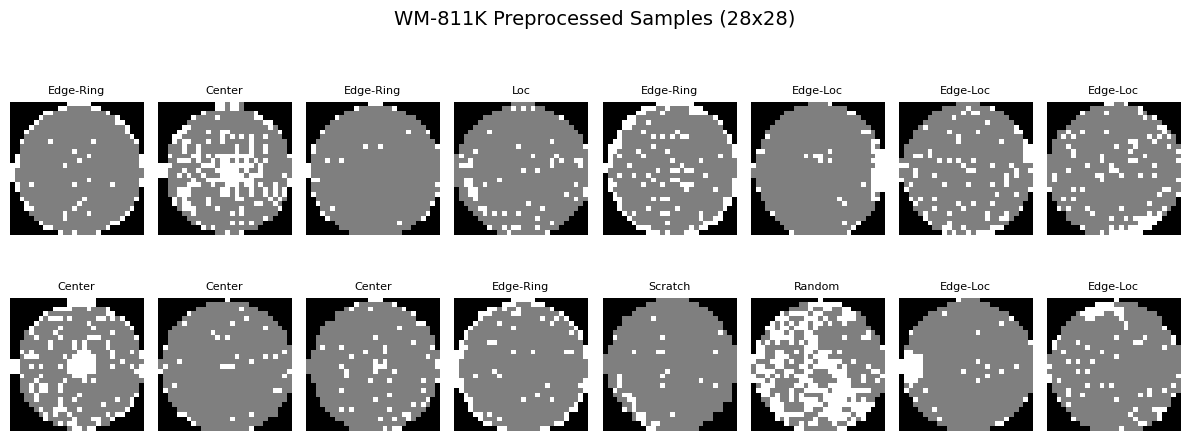

In [15]:
# 배치 샘플 시각화
if 'dataloader' in locals():
    # 배치 하나 가져오기
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"WM-811K Preprocessed Samples ({IMG_SIZE}x{IMG_SIZE})", fontsize=14)
    
    for i in range(min(16, len(images))):
        ax = plt.subplot(2, 8, i + 1)
        
        # [-1, 1] -> [0, 1] 범위로 복원하여 시각화
        img = (images[i] * 0.5 + 0.5).permute(1, 2, 0).numpy()
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        
        # 클래스 이름 표시
        label_idx = labels[i].item()
        class_name = dataset.idx_to_class[label_idx]
        plt.title(f"{class_name}", fontsize=8)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

#### 3.7.5 클래스 분포 분석


Class Name      | Count    | Ratio     
----------------------------------------
Center          | 4294     | 16.83%
Donut           | 555      | 2.17%
Edge-Loc        | 5189     | 20.33%
Edge-Ring       | 9680     | 37.93%
Loc             | 3593     | 14.08%
Near-full       | 149      | 0.58%
Random          | 866      | 3.39%
Scratch         | 1193     | 4.67%
Total Samples: 25519


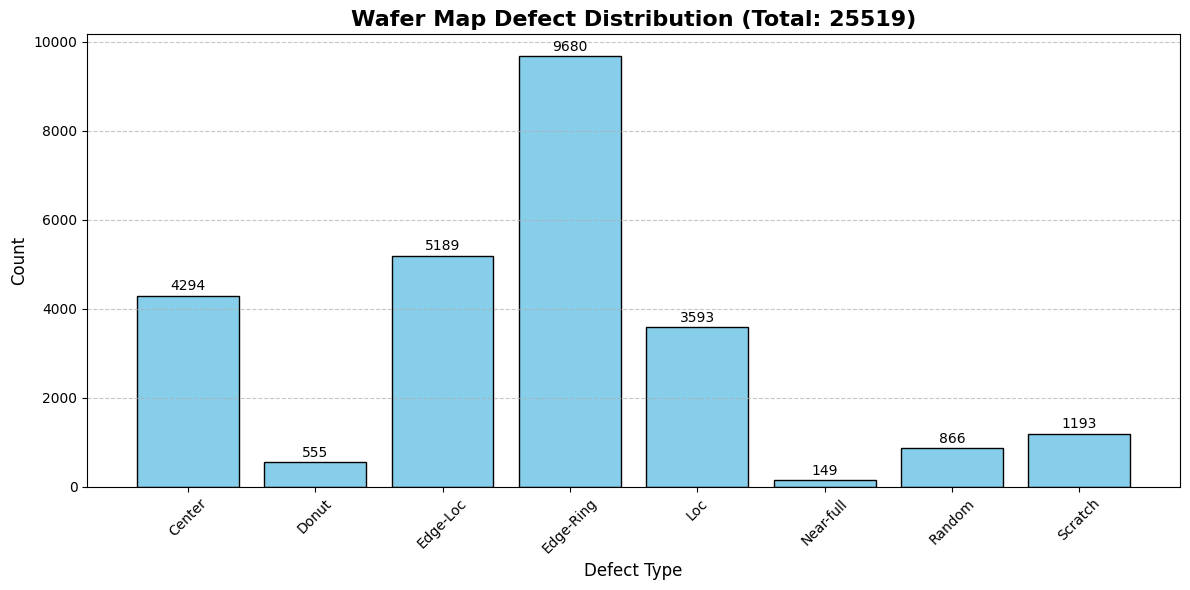

In [16]:
from collections import Counter

# 모든 데이터의 라벨 수집
all_labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    label_val = label.item() if hasattr(label, 'item') else label
    all_labels.append(label_val)

# 클래스별 개수 세기
counts = Counter(all_labels)
total_samples = len(all_labels)

# 정렬 (인덱스 순서대로)
sorted_indices = sorted(counts.keys())
class_names = [dataset.idx_to_class[idx] for idx in sorted_indices]
values = [counts[idx] for idx in sorted_indices]

# 텍스트로 상세 비율 출력
print(f"\n{'='*40}")
print(f"{'Class Name':<15} | {'Count':<8} | {'Ratio':<10}")
print(f"{'-'*40}")
for name, val in zip(class_names, values):
    ratio = (val / total_samples) * 100
    print(f"{name:<15} | {val:<8} | {ratio:.2f}%")
print(f"{'='*40}")
print(f"Total Samples: {total_samples}")

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, values, color='skyblue', edgecolor='black')

plt.title(f'Wafer Map Defect Distribution (Total: {total_samples})', 
          fontsize=16, fontweight='bold')
plt.xlabel('Defect Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 개수 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 50, 
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### 3.7.6 클래스 불균형 해결

In [17]:
from torch.utils.data import WeightedRandomSampler

# 클래스별 샘플 개수 
class_counts = [4294, 555, 5189, 9680, 3593, 149, 866, 1193]

# 클래스별 가중치 계산 
num_samples = sum(class_counts)
class_weights = [num_samples / c for c in class_counts]

# 각 샘플에 가중치 부여
all_labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    all_labels.append(label.item() if hasattr(label, 'item') else label)

# 샘플별 가중치 매핑
sample_weights = [class_weights[label] for label in all_labels]

# Weighted Sampler 생성
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # 중복 샘플링 허용 (희소 클래스 보강)
)

# DataLoader 재정의
dataloader = DataLoader(
    dataset,
    batch_size=128,
    sampler=sampler,      # Sampler 연결
    shuffle=False,        
    num_workers=0,
    pin_memory=True
)

#### 3.7.7 최종 데이터 확인

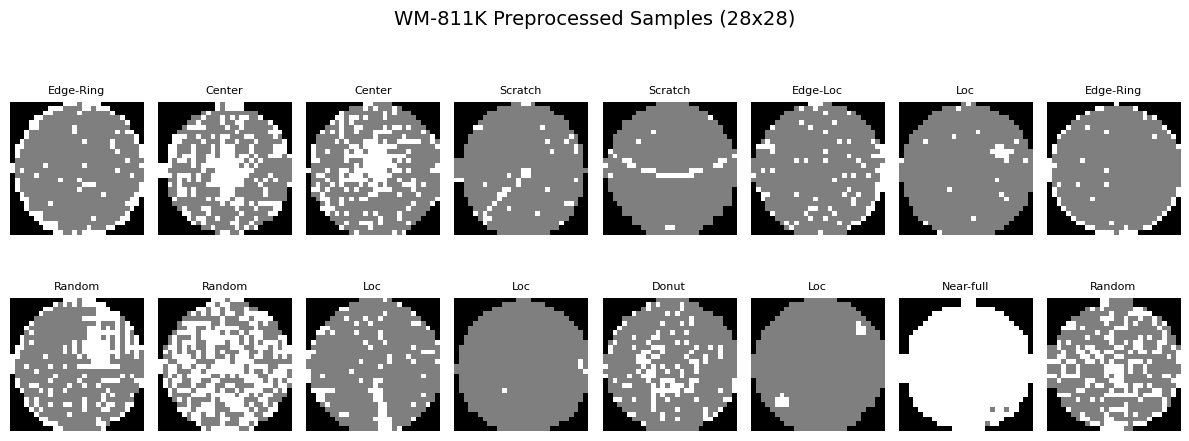

In [18]:
# 배치 시각화 
if 'dataloader' in locals():
    images, labels = next(iter(dataloader))
    
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"WM-811K Preprocessed Samples ({IMG_SIZE}x{IMG_SIZE})", fontsize=14)
    
    for i in range(min(16, len(images))):
        ax = plt.subplot(2, 8, i + 1)
        
        # [-1, 1] -> [0, 1] 복원
        img = (images[i] * 0.5 + 0.5).permute(1, 2, 0).numpy()
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        
        label_idx = labels[i].item()
        class_name = dataset.idx_to_class[label_idx]
        plt.title(f"{class_name}", fontsize=8)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

#### 3.7.8 시각화 함수

In [19]:
def show_images(images, title="", labels=None, class_names=None):

    # 튜플로 들어온 경우 분리
    if isinstance(images, tuple):
        images, labels = images
    
    # GPU 텐서 -> CPU 변환
    if isinstance(images, torch.Tensor):
        images = images.cpu().detach()
    if labels is not None and isinstance(labels, torch.Tensor):
        labels = labels.cpu().detach()
    
    # 이미지 정규화 ([-1, 1] -> [0, 255])
    if isinstance(images, torch.Tensor):
        images = (images.clamp(-1, 1) + 1) / 2  # [-1,1] -> [0,1]
        images = (images * 255).type(torch.uint8).numpy()
    
    # Grid 크기 계산 (정사각형에 가깝게)
    n_images = len(images)
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))
    
    # 그리드 생성
    fig = plt.figure(figsize=(12, 12))
    
    for idx in range(n_images):
        ax = fig.add_subplot(rows, cols, idx + 1)
        
        # 이미지 표시 (Grayscale vs RGB)
        if images[idx].shape[0] == 1:  # Grayscale
            ax.imshow(images[idx][0], cmap="gray")
        else:  # RGB
            ax.imshow(images[idx].transpose(1, 2, 0))
        
        # 라벨 표시
        if labels is not None:
            label_idx = labels[idx].item() if hasattr(labels[idx], 'item') else labels[idx]
            
            if class_names is not None:
                label_text = class_names[label_idx]
            else:
                label_text = f"Class {label_idx}"
            
            ax.set_title(label_text, fontsize=10, fontweight='bold')
        
        ax.axis('off')
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [20]:
# Shows the first batch of images
def show_first_batch(loader):
    for batch in loader:
        show_images(batch[0], "Images in the first batch")
        break

In [21]:
# 모델 학습에 필요한 정보
NUM_CLASSES = len(dataset.classes)  # 8개 결함 클래스
IMG_CHANNELS = 1                     # Grayscale 이미지
IMG_SIZE = 28                        # 이미지 크기
BATCH_SIZE = 128                     # 배치 크기

print(f"설정 완료:")
print(f"   - Classes: {NUM_CLASSES}")
print(f"   - Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - Channels: {IMG_CHANNELS}")
print(f"   - Batch Size: {BATCH_SIZE}")

# 배치 shape 확인
images, labels = next(iter(dataloader))
print(f"\nBatch 확인:")
print(f"   - Images: {images.shape}")      # [128, 1, 28, 28]
print(f"   - Labels: {labels.shape}")      # [128]
print(f"   - Image range: [{images.min():.2f}, {images.max():.2f}]")  # [-1.00, 1.00]

설정 완료:
   - Classes: 8
   - Image Size: 28x28
   - Channels: 1
   - Batch Size: 128

Batch 확인:
   - Images: torch.Size([128, 1, 28, 28])
   - Labels: torch.Size([128])
   - Image range: [-1.00, 1.00]


## 4. DDPM 및 DDIM 구현

### 4.1 모델 구현 환경 설정

In [22]:
# Setting reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Definitions
STORE_PATH_MNIST = "ddpm_model_HW08.pt"
STORE_PATH_FASHION = "ddpm_model_HW08.pt"

In [23]:
no_train = False
fashion = False
batch_size = 128
n_epochs = 200
lr = 0.001
store_path = "ddpm_wafer.pt"

In [24]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    
print(device)

cuda


### 4.2 유틸리티 함수

In [25]:
def show_forward(ddpm, loader, device):
    # Showing the forward process
    for batch in loader:
        imgs = batch[0]

        show_images(imgs, "Original images")

        for percent in [0.25, 0.5, 0.75, 1]:
            show_images(
                ddpm(imgs.to(device),
                     [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))]),
                f"DDPM Noisy images {int(percent * 100)}%"
            )
        break

In [26]:
def generate_new_images(ddpm, n_samples=16, device=None, 
                        classes=None,
                        frames_per_gif=100, gif_name="sampling.gif", 
                        c=1, h=28, w=28):

    # GIF 저장용 프레임 인덱스 계산
    frame_idxs = np.linspace(0, ddpm.n_steps, frames_per_gif).astype(np.uint)
    frames = []
    
    with torch.no_grad():
        if device is None:
            device = ddpm.device
        
        # 클래스 라벨 설정 (None이면 랜덤 생성)
        if classes is None:
            classes = torch.randint(0, 8, (n_samples,))
        classes = classes.to(device).long()
        
        # 순수 가우시안 노이즈에서 시작
        x = torch.randn(n_samples, c, h, w).to(device)
        
        # Reverse diffusion: t = T → 0
        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            # Timestep 텐서 생성 (모든 샘플에 동일한 t)
            time_tensor = torch.full((n_samples,), t, device=device).long()
            
            # 노이즈 예측: ε_θ(x_t, t, y)
            eta_theta = ddpm.backward(x, time_tensor, classes)
            
            # α_t, ᾱ_t 가져오기
            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]
            
            # Denoising step: x_{t-1} = μ_θ(x_t, t) + σ_t·z
            # μ_θ = (1/√α_t) · (x_t - (1-α_t)/√(1-ᾱ_t) · ε_θ)
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)
            
            # t > 0일 때만 노이즈 추가 (stochastic)
            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)
                beta_t = ddpm.betas[t]
                sigma_t = beta_t.sqrt()
                x = x + sigma_t * z
            
            # GIF 프레임 저장
            if idx in frame_idxs or t == 0:
                # 이미지 정규화 [min, max] → [0, 255]
                normalized = x.clone()
                for i in range(len(normalized)):
                    normalized[i] -= torch.min(normalized[i])
                    normalized[i] *= 255 / torch.max(normalized[i])
                
                # Grid 형태로 배열 (sqrt(n) x sqrt(n))
                frame = einops.rearrange(
                    normalized, 
                    "(b1 b2) c h w -> (b1 h) (b2 w) c", 
                    b1=int(n_samples ** 0.5)
                )
                frame = frame.cpu().numpy().astype(np.uint8)
                
                # Grayscale인 경우 차원 제거
                if frame.ndim == 3 and frame.shape[-1] == 1:
                    frame = frame.squeeze(-1)
                
                frames.append(frame)

    with imageio.get_writer(gif_name, mode="I") as writer:
        for idx, frame in enumerate(frames):
            writer.append_data(frame)
            if idx == len(frames) - 1:
                for _ in range(frames_per_gif // 3):
                    writer.append_data(frames[-1])
    
    return x, classes

### 4.3 DDPM 모델 구현

#### 4.3.1 MyDDPM 클래스

In [27]:
class MyDDPM(nn.Module):
    def __init__(self, network, n_steps=200, min_beta=10 ** -4, max_beta=0.02, device=None, image_chw=(1, 28, 28)):
        super(MyDDPM, self).__init__()
        self.n_steps = n_steps
        self.device = device
        self.image_chw = image_chw
        self.network = network.to(device)
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.tensor([torch.prod(self.alphas[:i + 1]) for i in range(len(self.alphas))]).to(device)
    
    def forward(self, x0, t, eta=None):
        n, c, h, w = x0.shape
        a_bar = self.alpha_bars[t]
        
        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)
        
        noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        return noisy
    
    def backward(self, x, t, y):  # ← y 추가
        return self.network(x, t, y)

#### 4.3.2 MyBlock - 기본 Convolutional Block

In [28]:
class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(MyBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out

#### 4.3.3 Sinusoidal Position Embedding

In [29]:
def sinusoidal_embedding(n, d):
    # Returns the standard positional embedding
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)])
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    embedding[:,::2] = torch.sin(t * wk[:,::2])
    embedding[:,1::2] = torch.cos(t * wk[:,::2])

    return embedding

#### 4.3.4 Class-Conditional U-Net

In [106]:
class MyUNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100, num_classes=8):
        super(MyUNet, self).__init__()
        
        # Time embedding (
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)  # Freeze
        
        # Class embedding
        self.class_embed = nn.Embedding(num_classes, time_emb_dim)
        
        # Encoder (Downsampling Path)
        # Level 1: 28x28 -> 14x14
        self.te1 = self._make_te(time_emb_dim * 2, 1)  # Time + Class = 200 dim
        self.b1 = nn.Sequential(
            MyBlock((1, 28, 28), 1, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10)
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)  # Downsample
        
        # Level 2: 14x14 -> 7x7
        self.te2 = self._make_te(time_emb_dim * 2, 10)
        self.b2 = nn.Sequential(
            MyBlock((10, 14, 14), 10, 20),
            MyBlock((20, 14, 14), 20, 20),
            MyBlock((20, 14, 14), 20, 20)
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)
        
        # Level 3: 7x7 -> 3x3
        self.te3 = self._make_te(time_emb_dim * 2, 20)
        self.b3 = nn.Sequential(
            MyBlock((20, 7, 7), 20, 40),
            MyBlock((40, 7, 7), 40, 40),
            MyBlock((40, 7, 7), 40, 40)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(40, 40, 2, 1),
            nn.SiLU(),
            nn.Conv2d(40, 40, 4, 2, 1)
        )
        
        # Bottleneck 
        self.te_mid = self._make_te(time_emb_dim * 2, 40)
        self.b_mid = nn.Sequential(
            MyBlock((40, 3, 3), 40, 20),
            MyBlock((20, 3, 3), 20, 20),
            MyBlock((20, 3, 3), 20, 40)
        )
        
        # Decoder (Upsampling Path) 
        # Level 1: 3x3 -> 7x7
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(40, 40, 4, 2, 1),  # Upsample
            nn.SiLU(),
            nn.ConvTranspose2d(40, 40, 2, 1)
        )
        self.te4 = self._make_te(time_emb_dim * 2, 80)  # Skip connection: 40 + 40 = 80
        self.b4 = nn.Sequential(
            MyBlock((80, 7, 7), 80, 40),
            MyBlock((40, 7, 7), 40, 20),
            MyBlock((20, 7, 7), 20, 20)
        )
        
        # Level 2: 7x7 -> 14x14
        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)
        self.te5 = self._make_te(time_emb_dim * 2, 40)
        self.b5 = nn.Sequential(
            MyBlock((40, 14, 14), 40, 20),
            MyBlock((20, 14, 14), 20, 10),
            MyBlock((10, 14, 14), 10, 10)
        )
        
        # Level 3: 14x14 -> 28x28
        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)
        self.te_out = self._make_te(time_emb_dim * 2, 20)
        self.b_out = nn.Sequential(
            MyBlock((20, 28, 28), 20, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10, normalize=False)  # 마지막은 정규화 X
        )
        
        # 최종 출력층 (노이즈 예측)
        self.conv_out = nn.Conv2d(10, 1, 3, 1, 1)
    
    def forward(self, x, t, y):

        # Time embedding과 Class embedding 결합
        t_emb = self.time_embed(t)       # [N, 100]
        c_emb = self.class_embed(y)      # [N, 100]
        emb = torch.cat([t_emb, c_emb], dim=-1)  # [N, 200]
        
        n = len(x)
        
        # Encoder
        out1 = self.b1(x + self.te1(emb).reshape(n, -1, 1, 1))  # [N, 10, 28, 28]
        out2 = self.b2(self.down1(out1) + self.te2(emb).reshape(n, -1, 1, 1))  # [N, 20, 14, 14]
        out3 = self.b3(self.down2(out2) + self.te3(emb).reshape(n, -1, 1, 1))  # [N, 40, 7, 7]
        
        # Bottleneck
        out_mid = self.b_mid(self.down3(out3) + self.te_mid(emb).reshape(n, -1, 1, 1))  # [N, 40, 3, 3]
        
        # Decoder (skip connections 결합)
        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # [N, 80, 7, 7]
        out4 = self.b4(out4 + self.te4(emb).reshape(n, -1, 1, 1))
        
        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # [N, 40, 14, 14]
        out5 = self.b5(out5 + self.te5(emb).reshape(n, -1, 1, 1))
        
        out = torch.cat((out1, self.up3(out5)), dim=1)  # [N, 20, 28, 28]
        out = self.b_out(out + self.te_out(emb).reshape(n, -1, 1, 1))
        
        # 최종 노이즈 예측
        out = self.conv_out(out)  # [N, 1, 28, 28]
        
        return out
    
    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )

### 4.3 모델 초기화 및 사전 확인

In [31]:
n_steps = 1000              # Total diffusion steps
min_beta = 10 ** -4         # β_1 = 0.0001
max_beta = 0.02             # β_T = 0.02
NUM_CLASSES = 8             # 웨이퍼 결함 클래스 개수

In [32]:
# DDPM 모델 생성
ddpm = MyDDPM(
    MyUNet(n_steps, time_emb_dim=100, num_classes=NUM_CLASSES),
    n_steps=n_steps,
    min_beta=min_beta,
    max_beta=max_beta,
    device=device
)

In [33]:
ddpm

MyDDPM(
  (network): MyUNet(
    (time_embed): Embedding(1000, 100)
    (class_embed): Embedding(8, 100)
    (te1): Sequential(
      (0): Linear(in_features=200, out_features=1, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1, out_features=1, bias=True)
    )
    (b1): Sequential(
      (0): MyBlock(
        (ln): LayerNorm((1, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (1): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (2): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): C

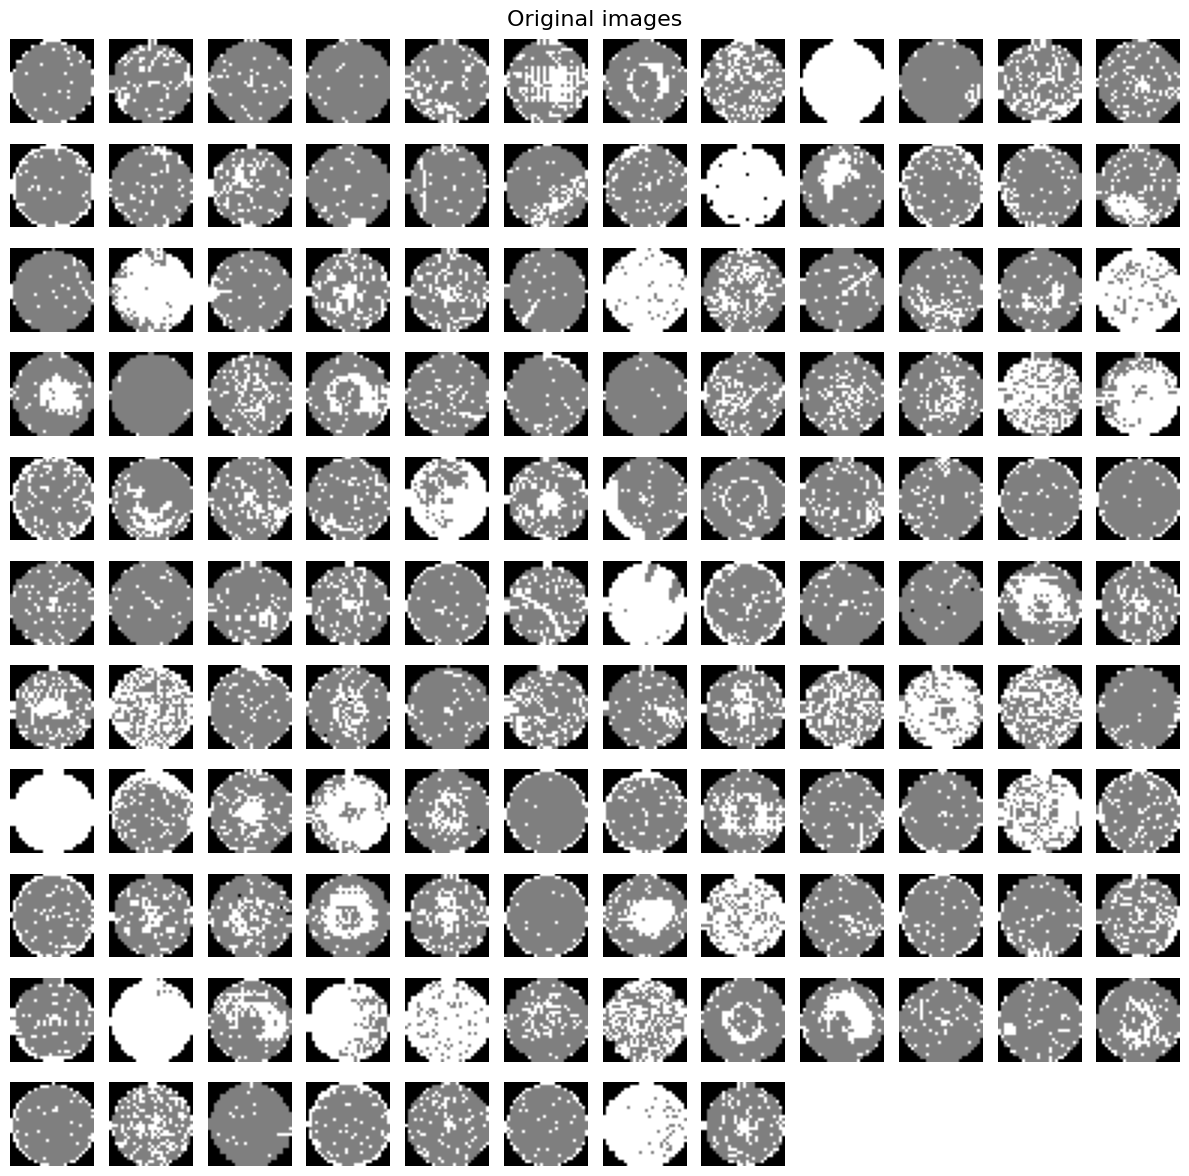

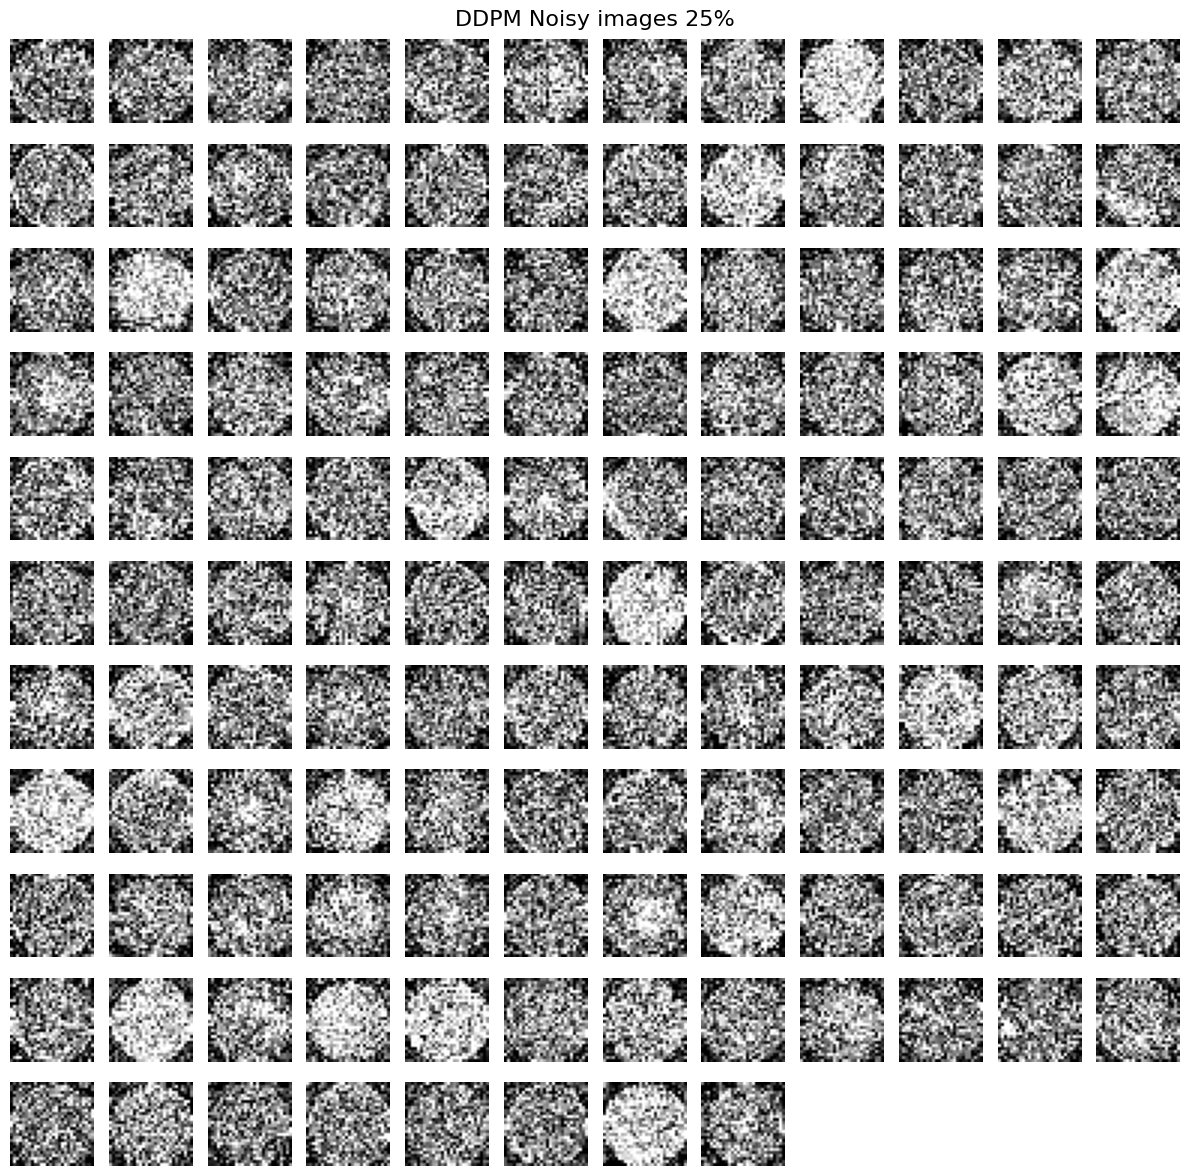

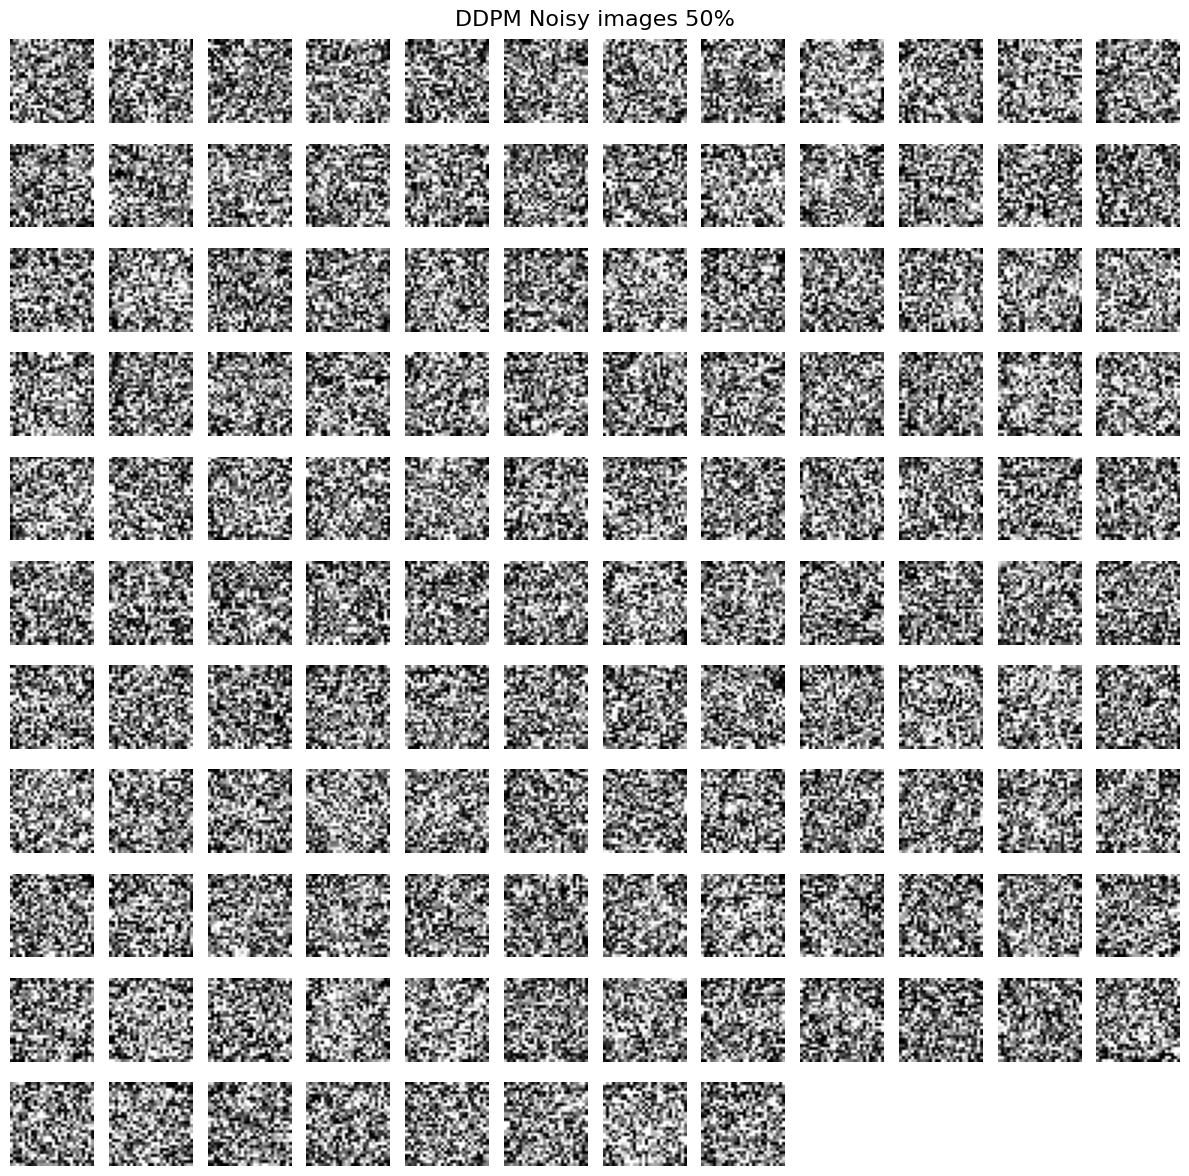

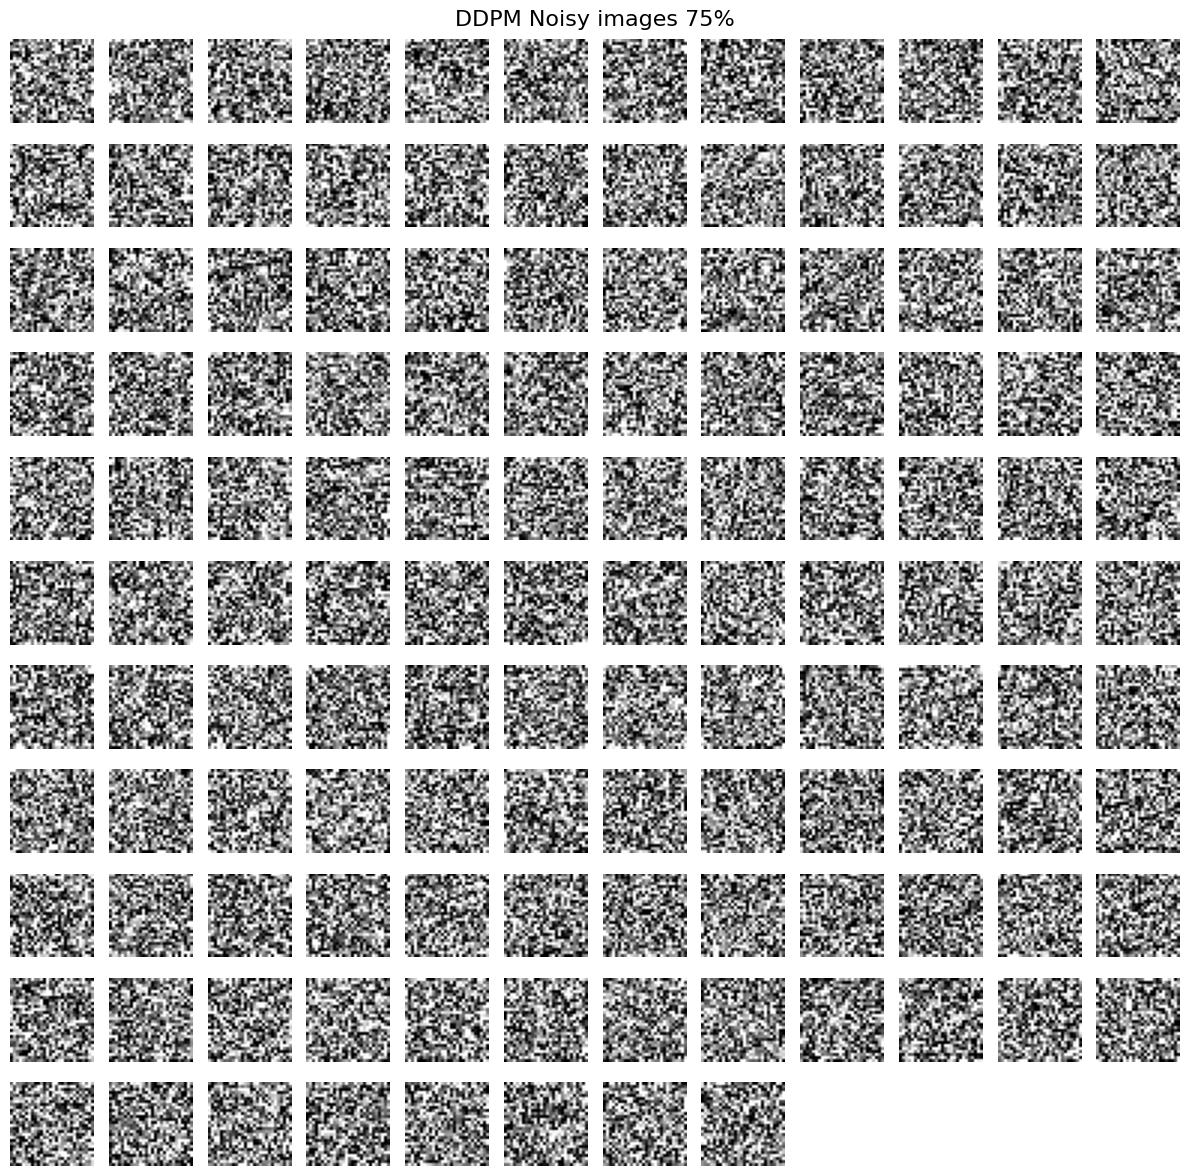

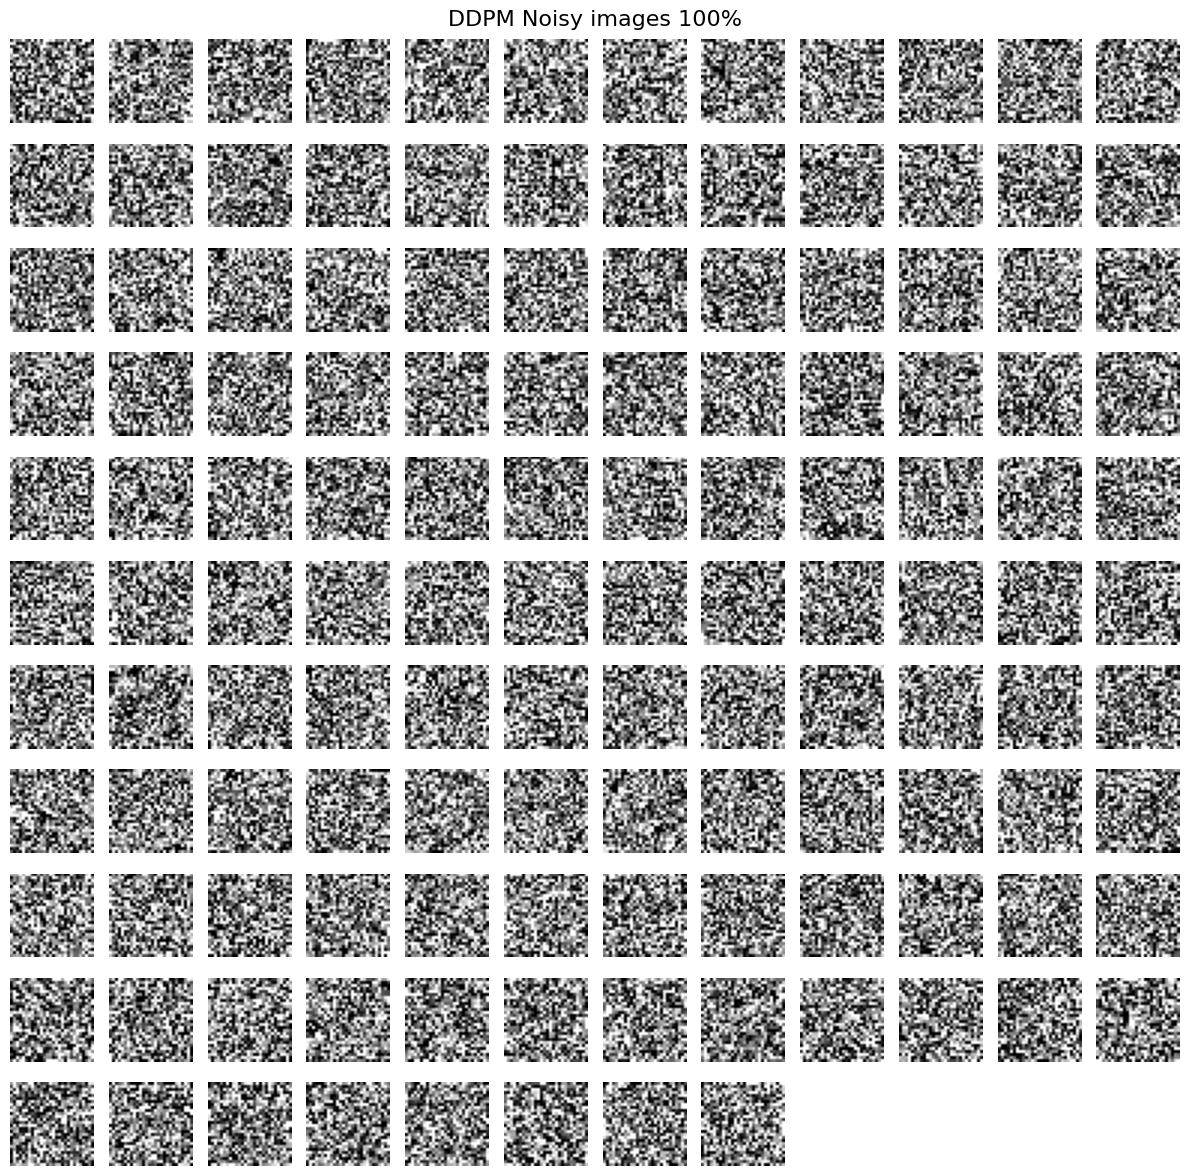

In [34]:
# Optionally, show the diffusion (forward) process
show_forward(ddpm, dataloader, device)

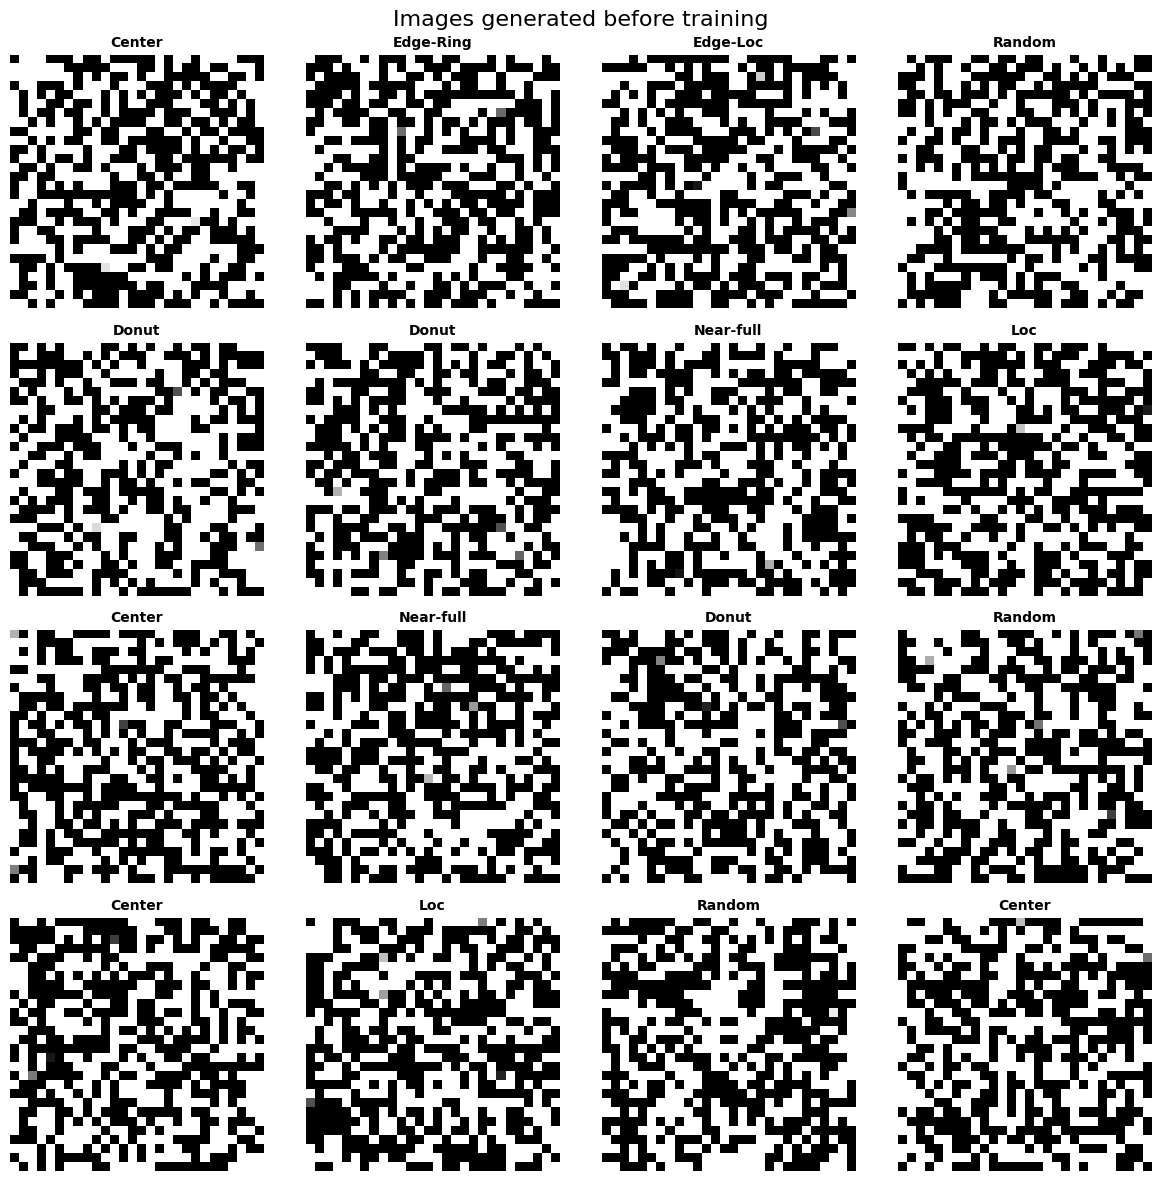

In [35]:
# 클래스 이름 준비
class_names = list(dataset.idx_to_class.values())

# 생성
generated, gen_classes = generate_new_images(ddpm, gif_name="before_training.gif")

# 라벨과 함께 표시
show_images(
    generated, 
    "Images generated before training",
    labels=gen_classes,           
    class_names=class_names      
)

###  4.4 평가 지표 - FID

In [36]:
class InceptionFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.inception = inception_v3(pretrained=True, transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception.eval()
        for param in self.inception.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        x = (x + 1) / 2
        return self.inception(x)

In [37]:
def calculate_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

In [38]:
fid_model = InceptionFeatureExtractor().to(device)
real_features = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Extracting features"):
        x = batch[0].to(device)
        x = x.clamp(-1, 1)
        feat = fid_model(x).cpu().numpy()
        real_features.append(feat)

real_features = np.concatenate(real_features, axis=0)

Extracting features:   0%|          | 0/200 [00:00<?, ?it/s]

### 4.5 DDPM, DDIM  학습 및 이미지 생성

#### 4.5.1 학습 루프 구현

In [39]:
def training_loop(ddpm, loader, n_epochs, optim, device, display=False, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = ddpm.n_steps
    
    loss_history = []
    
    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{n_epochs}", colour="#005500")):
            x0 = batch[0].to(device)
            y = batch[1].to(device)
            n = len(x0)
            
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)
            
            noisy_imgs = ddpm(x0, t, eta)
            eta_theta = ddpm.backward(noisy_imgs, t, y)
            
            loss = mse(eta_theta, eta)
            optim.zero_grad()
            loss.backward()
            optim.step()
            
            epoch_loss += loss.item() * len(x0) / len(loader.dataset)
        
        loss_history.append(epoch_loss)
        
        if display:
            generated, gen_classes = generate_new_images(ddpm, device=device)
            show_images(generated, f"Images generated at epoch {epoch + 1}")
        
        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.5f}"
        
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model ever (stored)"
        
        print(log_string)
    
    # 학습 곡선
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_epochs + 1), loss_history, marker='o', linewidth=2, markersize=4)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('DDPM Training Loss', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.savefig('ddpm_training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    pd.DataFrame({'epoch': range(1, n_epochs + 1), 'loss': loss_history}).to_csv('ddpm_training_loss.csv', index=False)
    print("Loss saved to 'ddpm_training_loss.csv'")
    
    return loss_history

#### 4.5.2 DDPM/DDIM 생성 함수

In [40]:
def generate_ddpm_with_nfe(ddpm, n_samples=16, device=None, classes=None, c=1, h=28, w=28):
    if device is None:
        device = ddpm.device
    
    if classes is None:
        classes = torch.randint(0, 8, (n_samples,))
    classes = classes.to(device).long()
    
    x = torch.randn(n_samples, c, h, w).to(device)
    nfe = 0
    start_time = time.time()
    
    with torch.no_grad():
        ddpm.eval()
        for t in tqdm(range(ddpm.n_steps - 1, -1, -1), desc="DDPM", leave=False):
            time_tensor = torch.full((n_samples,), t, device=device).long()
            eta_theta = ddpm.backward(x, time_tensor, classes)
            nfe += 1
            
            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]
            
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)
            x = x.clamp(-1, 1)
            
            if t > 0:
                z = torch.randn_like(x)
                x = x + ddpm.betas[t].sqrt() * z
                x = x.clamp(-1, 1)
    
    return x, classes, nfe, time.time() - start_time

In [41]:
def generate_ddim_with_nfe(ddpm, n_samples=16, device=None, classes=None,
                            ddim_steps=50, eta=0.0, c=1, h=28, w=28):
    if device is None:
        device = ddpm.device
    
    if classes is None:
        classes = torch.randint(0, 8, (n_samples,))
    classes = classes.to(device).long()
    
    times = torch.linspace(0, ddpm.n_steps - 1, steps=ddim_steps + 1).round().long().to(device)
    times = list(reversed(times.tolist()))
    time_pairs = list(zip(times[:-1], times[1:]))
    
    x = torch.randn(n_samples, c, h, w).to(device)
    nfe = 0
    start_time = time.time()
    
    with torch.no_grad():
        ddpm.eval()
        
        for t, prev_t in tqdm(time_pairs, desc=f"DDIM-{ddim_steps}", leave=False):
            time_tensor = torch.full((n_samples,), t, device=device).long()
            eta_theta = ddpm.backward(x, time_tensor, classes)
            nfe += 1
            
            alpha_bar_t = ddpm.alpha_bars[t]
            alpha_bar_prev = ddpm.alpha_bars[prev_t] if prev_t >= 0 else torch.tensor(1.0).to(device)
            
            sigma_t = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev))
            
            # pred_x0 with clamp
            pred_x0 = (x - torch.sqrt(1 - alpha_bar_t) * eta_theta) / torch.sqrt(alpha_bar_t)
            pred_x0 = pred_x0.clamp(-1, 1)  # 추가!
            
            dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma_t**2) * eta_theta
            
            if sigma_t > 0:
                noise = sigma_t * torch.randn_like(x)
            else:
                noise = 0.
            
            x = torch.sqrt(alpha_bar_prev) * pred_x0 + dir_xt + noise
    
    return x, classes, nfe, time.time() - start_time

#### 4.5.3 FID 계산 함수

In [42]:
def calc_fid(ddpm, method='ddpm', ddim_steps=50, n_samples=1000):
    print(f"FID for {method.upper()}...")
    fake_features = []
    
    for _ in tqdm(range(n_samples // 100), desc="Generating"):
        if method == 'ddpm':
            imgs, _, _, _ = generate_ddpm_with_nfe(ddpm, 100, device)
        else:
            imgs, _, _, _ = generate_ddim_with_nfe(ddpm, 100, device, ddim_steps=ddim_steps)
        
        feat = fid_model(imgs.clamp(-1, 1)).cpu().numpy()
        fake_features.append(feat)
    
    fake_features = np.concatenate(fake_features)
    return calculate_fid(real_features, fake_features)

#### 4.5.4 DDPM vs DDIM 종합 비교

In [43]:
def compare_ddpm_ddim(ddpm):
    print("\n" + "="*70)
    print("DDPM vs DDIM Comparison")
    print("="*70)
    
    results = {'method': [], 'nfe': [], 'time': [], 'fid': []}
    
    # DDPM
    _, _, nfe_ddpm, time_ddpm = generate_ddpm_with_nfe(ddpm, 100, device)
    fid_ddpm = calc_fid(ddpm, 'ddpm')
    
    results['method'].append('DDPM')
    results['nfe'].append(nfe_ddpm)
    results['time'].append(time_ddpm)
    results['fid'].append(fid_ddpm)
    
    # DDIM
    for steps in [50, 100, 200]:
        print(f"\nDDIM-{steps}...")
        _, _, nfe_ddim, time_ddim = generate_ddim_with_nfe(ddpm, 100, device, ddim_steps=steps)
        fid_ddim = calc_fid(ddpm, 'ddim', steps)
        
        results['method'].append(f'DDIM-{steps}')
        results['nfe'].append(nfe_ddim)
        results['time'].append(time_ddim)
        results['fid'].append(fid_ddim)
    
    df = pd.DataFrame(results)
    print("\n" + df.to_string(index=False))
    
    # 그래프
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ['blue', 'green', 'lightgreen', 'lime']
    
    axes[0, 0].bar(df['method'], df['nfe'], color=colors)
    axes[0, 0].set_title('NFE', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    axes[0, 1].bar(df['method'], df['time'], color=colors)
    axes[0, 1].set_title('Time (100 samples)', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    axes[1, 0].bar(df['method'], df['fid'], color=colors)
    axes[1, 0].set_title('FID Score', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    axes[1, 1].scatter(df['nfe'], df['fid'], s=200, c=colors)
    for i, m in enumerate(df['method']):
        axes[1, 1].annotate(m, (df['nfe'][i], df['fid'][i]), ha='center', va='bottom')
    axes[1, 1].set_xlabel('NFE')
    axes[1, 1].set_ylabel('FID')
    axes[1, 1].set_title('NFE vs FID', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ddpm_ddim_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    df.to_csv('results.csv', index=False)
    print("Saved: results.csv, ddpm_ddim_comparison.png")
    
    return df

#### 4.5.5 모델 학습 실행 및 평가

Starting training...


Training progress:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/200:   0%|          | 0/200 [00:00<?, ?it/s]

Loss at epoch 1: 0.33374 --> Best model ever (stored)


Epoch 2/200:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loss at epoch 198: 0.04820


Epoch 199/200:   0%|          | 0/200 [00:00<?, ?it/s]

Loss at epoch 199: 0.04915


Epoch 200/200:   0%|          | 0/200 [00:00<?, ?it/s]

Loss at epoch 200: 0.04664 --> Best model ever (stored)


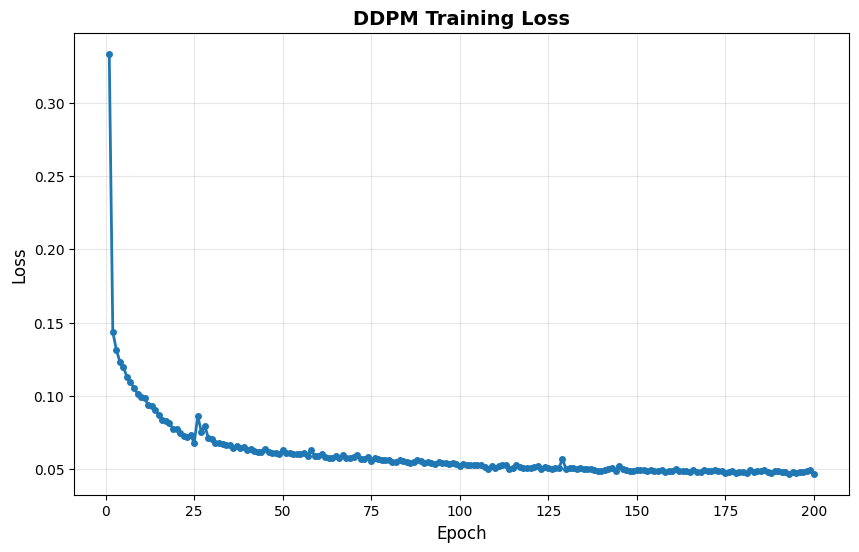

Loss saved to 'ddpm_training_loss.csv'


In [44]:
store_path = "ddpm_wafer.pt"

if not no_train:
    print("Starting training...")
    loss_history = training_loop(
        ddpm, dataloader, n_epochs, 
        optim=Adam(ddpm.parameters(), lr), 
        device=device, store_path=store_path
    )

In [45]:
best_model = MyDDPM(
    MyUNet(n_steps=n_steps, num_classes=8),
    n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device
)
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()

MyDDPM(
  (network): MyUNet(
    (time_embed): Embedding(1000, 100)
    (class_embed): Embedding(8, 100)
    (te1): Sequential(
      (0): Linear(in_features=200, out_features=1, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1, out_features=1, bias=True)
    )
    (b1): Sequential(
      (0): MyBlock(
        (ln): LayerNorm((1, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (1): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): SiLU()
      )
      (2): MyBlock(
        (ln): LayerNorm((10, 28, 28), eps=1e-05, elementwise_affine=True)
        (conv1): C

#### 4.5.6 클래스별 이미지 생성 및 저장

In [46]:
class_names = list(dataset.idx_to_class.values())
NUM_CLASSES = len(class_names)
SAMPLES_PER_CLASS = 1000

In [47]:
os.makedirs("images/real", exist_ok=True)
os.makedirs("images/ddpm", exist_ok=True)
os.makedirs("images/ddim", exist_ok=True)

In [48]:
# 클래스별로 실제 데이터 수집
real_images_by_class = {i: [] for i in range(NUM_CLASSES)}

for batch_idx, (images, labels) in enumerate(tqdm(dataloader, desc="Collecting real images")):
    for img, label in zip(images, labels):
        class_idx = label.item()
        if len(real_images_by_class[class_idx]) < SAMPLES_PER_CLASS:
            real_images_by_class[class_idx].append(img)

# 저장
for class_idx in range(NUM_CLASSES):
    class_dir = f"images/real/class_{class_idx}_{class_names[class_idx]}"
    os.makedirs(class_dir, exist_ok=True)
    
    imgs = real_images_by_class[class_idx][:SAMPLES_PER_CLASS]
    print(f"   Class {class_idx} ({class_names[class_idx]}): {len(imgs)} images")
    
    for i, img in enumerate(imgs):
        # [-1, 1] -> [0, 255]
        img_array = ((img.squeeze() + 1) / 2 * 255).clamp(0, 255).numpy().astype(np.uint8)
        pil_img = PILImage.fromarray(img_array, mode='L')
        pil_img.save(f"{class_dir}/img_{i:04d}.png")


   Class 0 (Center): 1000 images
   Class 1 (Donut): 1000 images
   Class 2 (Edge-Loc): 1000 images
   Class 3 (Edge-Ring): 1000 images
   Class 4 (Loc): 1000 images
   Class 5 (Near-full): 1000 images
   Class 6 (Random): 1000 images
   Class 7 (Scratch): 1000 images


In [49]:
for class_idx in range(NUM_CLASSES):
    class_dir = f"images/ddpm/class_{class_idx}_{class_names[class_idx]}"
    os.makedirs(class_dir, exist_ok=True)
    
    print(f"   Class {class_idx} ({class_names[class_idx]}): 0/{SAMPLES_PER_CLASS}", end="")
    
    # 100개씩 생성
    batch_size = 100
    n_batches = SAMPLES_PER_CLASS // batch_size
    
    for batch_idx in range(n_batches):
        # 특정 클래스만 생성
        specific_class = torch.full((batch_size,), class_idx, dtype=torch.long)
        
        imgs, _, _, _ = generate_ddpm_with_nfe(
            best_model, 
            n_samples=batch_size, 
            classes=specific_class, 
            device=device
        )
        
        # 저장
        for i, img in enumerate(imgs):
            img_idx = batch_idx * batch_size + i
            # [-1, 1] -> [0, 255]
            img_array = ((img.cpu().squeeze() + 1) / 2 * 255).clamp(0, 255).numpy().astype(np.uint8)
            pil_img = PILImage.fromarray(img_array, mode='L')
            pil_img.save(f"{class_dir}/img_{img_idx:04d}.png")
        
        print(f"\r   Class {class_idx} ({class_names[class_idx]}): {(batch_idx+1)*batch_size}/{SAMPLES_PER_CLASS}", end="")

   Class 0 (Center): 0/1000

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

   Class 0 (Center): 100/1000

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

   Class 0 (Center): 200/1000

...

   Class 7 (Scratch): 800/1000

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

   Class 7 (Scratch): 900/1000

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

   Class 7 (Scratch): 1000/1000

In [50]:
for DDIM_STEPS in [50, 100, 200]:
    print(f"\n  DDIM-{DDIM_STEPS} (NFE={DDIM_STEPS}):")
    
    for class_idx in range(NUM_CLASSES):
        class_dir = f"images/ddim_{DDIM_STEPS}/class_{class_idx}_{class_names[class_idx]}"
        os.makedirs(class_dir, exist_ok=True)
        
        print(f"   Class {class_idx} ({class_names[class_idx]}): 0/{SAMPLES_PER_CLASS}", end="")
        
        batch_size = 100
        n_batches = SAMPLES_PER_CLASS // batch_size
        
        for batch_idx in range(n_batches):
            specific_class = torch.full((batch_size,), class_idx, dtype=torch.long)
            
            imgs, _, _, _ = generate_ddim_with_nfe(
                best_model, 
                n_samples=batch_size, 
                classes=specific_class, 
                ddim_steps=DDIM_STEPS,
                device=device
            )
            
            for i, img in enumerate(imgs):
                img_idx = batch_idx * batch_size + i
                img_array = ((img.cpu().squeeze() + 1) / 2 * 255).clamp(0, 255).numpy().astype(np.uint8)
                pil_img = PILImage.fromarray(img_array, mode='L')
                pil_img.save(f"{class_dir}/img_{img_idx:04d}.png")
            
            print(f"\r   Class {class_idx} ({class_names[class_idx]}): {(batch_idx+1)*batch_size}/{SAMPLES_PER_CLASS}", end="")


  DDIM-50 (NFE=50):
   Class 0 (Center): 0/1000

DDIM-50:   0%|          | 0/50 [00:00<?, ?it/s]

   Class 0 (Center): 100/1000

DDIM-50:   0%|          | 0/50 [00:00<?, ?it/s]

   Class 0 (Center): 200/1000

...

   Class 7 (Scratch): 800/1000

DDIM-200:   0%|          | 0/200 [00:00<?, ?it/s]

   Class 7 (Scratch): 900/1000

DDIM-200:   0%|          | 0/200 [00:00<?, ?it/s]

   Class 7 (Scratch): 1000/1000

## 5. Consistency Models 구현

### 5.1 Consistency Models 구현

#### 5.1.1 EMA (Exponential Moving Average) 업데이트
* Student의 급격한 변화 방지
* Consistency loss 계산 시 moving target 역할
* Self-play 방식 - Student가 과거 자신과 비교하면 학습

In [54]:
def update_ema(target_model, student_model, decay=0.99999):
    with torch.no_grad():  # Gradient 계산 방지 (stop-gradient)
        for t_param, s_param in zip(target_model.parameters(), student_model.parameters()):
            # θ^- = μ · θ^- + (1 - μ) · θ
            t_param.data.mul_(decay).add_(s_param.data, alpha=1 - decay)

#### 5.1.2 ConsistencyModel 클래스

In [107]:
class ConsistencyModel(nn.Module):
    def __init__(self, network, n_steps=1000, device=None):
        super().__init__()
        self.n_steps = n_steps
        self.device = device
        self.network = network.to(device)  #Teacher DDPM의 U-Net 재사용
        
        # Noise schedule (Teacher와 동일)
        self.betas = torch.linspace(1e-4, 0.02, n_steps).to(device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)
        
        # Sigma schedule 
        self.sigma_min = 0.002
        self.sigma_max = 80.0
        
    def get_sigma(self, t):
        return torch.sqrt(1 - self.alpha_bars[t]) / torch.sqrt(self.alpha_bars[t])
    # DDPM은 1000번 반복해야 X_0 도달
    # CM은 한 번에 X_0로 점프 x_0 = (x_t - √(1-ᾱ_t)·ε) / √(ᾱ_t)
    def consistency_function(self, x, t, y):
        # 1단계: U-Net으로 노이즈 ε 예측
        eps_pred = self.network(x, t, y)
        # 2단계: x_0 역산 (DDPM reparameterization 역이용)
        alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
        x0_pred = (x - torch.sqrt(1 - alpha_bar) * eps_pred) / torch.sqrt(alpha_bar)  # x_0 역산
        # 3단계: 범위 제한 [-1, 1]  , 이걸로 Boundary Condidtion 처리 가능
        x0_pred = torch.tanh(x0_pred)  # [-1, 1] 범위 보장
        return x0_pred

#### 5.1.3 Consistency Distillation Loss
* 기본 원리: L_CD = E[d(f_θ(x_t, t), f_θ^-(x_{t-k}, t-k))]
* 인접 timestep 쌍의 출력이 일치하도록 학습
* Teacher DDPM으로 x_{t-k} 생성, Target CM으로 f^-(x_{t-k}, t-k) 계산

In [1]:
def consistency_distillation_loss(teacher_ddpm, student_cm, target_cm, x0, y, device):
    batch_size = x0.shape[0]
    n_steps = teacher_ddpm.n_steps
    
    # 비균등 샘플링
    u = torch.rand(batch_size, device=device)
    # 논문에서 권장하는 Importance Sampling(t가 큰 구간을 더 자주 샘플링해서 모델이 어려운 궤적을 먼저 익힘)
    t = (u ** 2 * (n_steps - 1)).long() + 1
    t = t.clamp(1, n_steps - 1)
    
    total_loss = 0
    
    # Multi-scale Consistency Distillation
    step_sizes = [1, 10, 50, 100, 200, 500, 700]
    
    # Consistency Loss : L_CD = Σ d(f_θ(x_t, t), f_θ^-(x_{t-k}, t-k))
    for step_size in step_sizes:
        t_prev = (t - step_size).clamp(0, n_steps - 1)
        
        # Forward diffusion: x_0 → x_t (DDPM forward process)
        # x_t = √(ᾱ_t)·x_0 + √(1-ᾱ_t)·ε
        noise = torch.randn_like(x0)
        alpha_bar_t = teacher_ddpm.alpha_bars[t].view(-1, 1, 1, 1)
        x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
        
        # Teacher DDPM으로 x_{t-k} 생성 (stop-gradient로 Teacher 고정)
        with torch.no_grad():
            teacher_ddpm.eval()
            # Teacher로 노이즈 예측
            eps_pred = teacher_ddpm.network(x_t, t, y)
            # Teacher의 x_0 예측
            pred_x0 = (x_t - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
            pred_x0 = pred_x0.clamp(-1, 1)
            
            # DDPM의 reverse step으로 x_{t-k} 생성
            # x_{t-k} = √(ᾱ_{t-k})·x̂_0 + √(1-ᾱ_{t-k})·ε
            alpha_bar_prev = teacher_ddpm.alpha_bars[t_prev].view(-1, 1, 1, 1)
            # Tracher의 PF-ODE가이드를 생성하는 부분
            x_t_prev = torch.sqrt(alpha_bar_prev) * pred_x0 + torch.sqrt(1 - alpha_bar_prev) * eps_pred
            
            # Target network로 f^-(x_{t-k}, t-k) 계산
            target_cm.eval()
            target_out = target_cm.consistency_function(x_t_prev, t_prev, y)
            
        # Consistency loss: d(f_θ(x_t, t), f_θ^-(x_{t-k}, t-k))
        # Self-consistency: 같은 궤적의 다른 점들이 같은 x_0를 가리키도록
        student_out = student_cm.consistency_function(x_t, t, y)
        # t지점의 출력과 t-1 지점의 출력이 같아지도록 하는 loss
        consistency_loss = F.smooth_l1_loss(student_out, target_out)
        total_loss += consistency_loss
    
    # Reconstruction loss
    noise = torch.randn_like(x0)
    alpha_bar_t = teacher_ddpm.alpha_bars[t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
    student_out = student_cm.consistency_function(x_t, t, y)
    # 추가적인 보조 Loss(t가 작을때 실제 데이터 X0를 잘 복원하는지 확인하는 항)
    recon_loss = F.smooth_l1_loss(student_out, x0)
    
    # Teacher distillation
    # Teacher DDPM의 x_0 예측 능력을 Student로 전달
    # Teacher가 이미 학습한 고품질 denoising 지식 활용
    with torch.no_grad():
        teacher_ddpm.eval()
        eps_pred = teacher_ddpm.network(x_t, t, y)
        teacher_x0 = (x_t - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
        teacher_x0 = teacher_x0.clamp(-1, 1)
    # Student 모델이 Teacher의 X0 예측 능력을 직접 닮게 만드는 Distillation 항
    teacher_loss = F.smooth_l1_loss(student_out, teacher_x0)
    
    loss = (total_loss / len(step_sizes)) + 2.0 * recon_loss + 1.0 * teacher_loss
    
    return loss

### 5.2 학습 루프 및 생성 함수
#### 5.2.1 Consistency Model 학습 루프

In [59]:
def train_consistency_model(teacher_ddpm, dataloader, n_epochs, device, 
                            lr=1e-4, store_path="cm_model.pt"):
    
    # Student 초기화
    student_network = copy.deepcopy(teacher_ddpm.network).to(device)
    student_cm = ConsistencyModel(student_network, n_steps=teacher_ddpm.n_steps, device=device)
    
    # Target (EMA)
    target_network = copy.deepcopy(teacher_ddpm.network).to(device)
    target_cm = ConsistencyModel(target_network, n_steps=teacher_ddpm.n_steps, device=device)
    target_cm.requires_grad_(False)
    target_cm.eval()
    
    optimizer = Adam(student_cm.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    best_loss = float("inf")
    loss_history = []
    total_steps = n_epochs * len(dataloader)
    current_step = 0
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        
        for batch in dataloader:
            x0 = batch[0].to(device)
            y = batch[1].to(device)
            
            loss = consistency_distillation_loss(teacher_ddpm, student_cm, target_cm, x0, y, device)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student_cm.parameters(), max_norm=1.0)
            optimizer.step()
            
            # EMA decay 스케줄링
            ema_decay = 0.9999 - (0.9999 - 0.99) * (1 - current_step / total_steps)
            update_ema(target_cm.network, student_cm.network, decay=ema_decay)
            
            current_step += 1
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        log_string = f"Epoch {epoch + 1}/{n_epochs}: {avg_loss:.5f}"
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(student_cm.state_dict(), store_path)
            log_string += " --> Best!"
        print(log_string)
    
    # Load best model
    student_cm.load_state_dict(torch.load(store_path))
    
    return student_cm, loss_history

#### 5.2.2 Consistency Model 생성 함수
* num_steps=1: 1-step generation 
* num_steps>1: multi-step generation

In [60]:
def generate_cm_with_nfe(cm, n_samples=16, device=None, classes=None, 
                          num_steps=1, c=1, h=28, w=28):
    if device is None:
        device = cm.device
    
    if classes is None:
        classes = torch.randint(0, 8, (n_samples,))
    classes = classes.to(device).long()
    
    nfe = 0
    start_time = time.time()
    
    with torch.no_grad():
        cm.eval()
        
        # Start from pure noise
        x = torch.randn(n_samples, c, h, w).to(device)
        
        if num_steps == 1:
            # 1-step generation
            # x_T → x_0 직접 매핑 (NFE=1)
            t = torch.full((n_samples,), cm.n_steps - 1, device=device).long()
            x = cm.consistency_function(x, t, classes)
            nfe = 1
        else:
            # Multi-step generation
            # Trajectory를 여러 구간으로 나눠 refinement
            timesteps = torch.linspace(cm.n_steps - 1, 0, num_steps + 1).long().tolist()
            
            for i in range(num_steps):
                t_cur = timesteps[i]
                t_next = timesteps[i + 1]
                
                t = torch.full((n_samples,), t_cur, device=device).long()
                
                # Denoise to x0
                x0_pred = cm.consistency_function(x, t, classes)
                nfe += 1
                
                if t_next > 0:
                    # Add noise back for next step
                    alpha_bar_next = cm.alpha_bars[t_next]
                    noise = torch.randn_like(x)
                    x = torch.sqrt(alpha_bar_next) * x0_pred + torch.sqrt(1 - alpha_bar_next) * noise
                else:
                    x = x0_pred
        
        x = x.clamp(-1, 1)
    
    return x, classes, nfe, time.time() - start_time

### 5.3 학습 실행 및 이미지 생성

#### 5.3.1 Consistency Model 학습

In [63]:
cm_model, cm_loss = train_consistency_model(
    teacher_ddpm=best_model,
    dataloader=dataloader,
    n_epochs=300,
    device=device,
    lr=2e-4,
    store_path="cm_model.pt"
)

Epoch 1/300: 0.22991 --> Best!
Epoch 2/300: 0.23505
Epoch 3/300: 0.23369
Epoch 4/300: 0.23085
Epoch 5/300: 0.22878 --> Best!
Epoch 6/300: 0.22830 --> Best!
Epoch 7/300: 0.22988
Epoch 8/300: 0.22491 --> Best!
Epoch 9/300: 0.22462 --> Best!
Epoch 10/300: 0.23192
Epoch 11/300: 0.23053
Epoch 12/300: 0.22837
Epoch 13/300: 0.23256
Epoch 14/300: 0.22672
Epoch 15/300: 0.22520
Epoch 16/300: 0.22686
Epoch 17/300: 0.21990 --> Best!
Epoch 18/300: 0.22355
Epoch 19/300: 0.22469
Epoch 20/300: 0.22319
Epoch 21/300: 0.22457
Epoch 22/300: 0.22853
Epoch 23/300: 0.22471
Epoch 24/300: 0.22325
Epoch 25/300: 0.22073
Epoch 26/300: 0.22442
Epoch 27/300: 0.22430
Epoch 28/300: 0.22859
Epoch 29/300: 0.22724
Epoch 30/300: 0.22434
Epoch 31/300: 0.22643
Epoch 32/300: 0.22720
Epoch 33/300: 0.22384
Epoch 34/300: 0.22224
Epoch 35/300: 0.23021
Epoch 36/300: 0.22376
Epoch 37/300: 0.22341
Epoch 38/300: 0.22693
Epoch 39/300: 0.22432
Epoch 40/300: 0.22855
Epoch 41/300: 0.22401
Epoch 42/300: 0.22436
Epoch 43/300: 0.22263
Epo

#### 5.3.2 클래스별 CM 이미지 생성

* one-step 생성

In [66]:
SAMPLES_PER_CLASS = 1000
CM_STEPS = 1  # One-step generation

for class_idx in range(NUM_CLASSES):
    class_dir = f"images/cm_1/class_{class_idx}_{class_names[class_idx]}"
    os.makedirs(class_dir, exist_ok=True)
    
    print(f"   Class {class_idx} ({class_names[class_idx]}): 0/{SAMPLES_PER_CLASS}", end="")
    
    batch_size = 100
    n_batches = SAMPLES_PER_CLASS // batch_size
    
    for batch_idx in range(n_batches):
        specific_class = torch.full((batch_size,), class_idx, dtype=torch.long)
        
        imgs, _, _, _ = generate_cm_with_nfe(
            cm_model, 
            n_samples=batch_size, 
            classes=specific_class,
            num_steps=CM_STEPS,  # NFE=1
            device=device
        )
        
        for i, img in enumerate(imgs):
            img_idx = batch_idx * batch_size + i
            img_array = ((img.cpu().squeeze() + 1) / 2 * 255).clamp(0, 255).numpy().astype(np.uint8)
            pil_img = PILImage.fromarray(img_array, mode='L')
            pil_img.save(f"{class_dir}/img_{img_idx:04d}.png")
        
        print(f"\r   Class {class_idx} ({class_names[class_idx]}): {(batch_idx+1)*batch_size}/{SAMPLES_PER_CLASS}", end="")
    print()

   Class 0 (Center): 1000/1000
   Class 1 (Donut): 1000/1000
   Class 2 (Edge-Loc): 1000/1000
   Class 3 (Edge-Ring): 1000/1000
   Class 4 (Loc): 1000/1000
   Class 5 (Near-full): 1000/1000
   Class 6 (Random): 1000/1000
   Class 7 (Scratch): 1000/1000


* multi-step 생성

In [67]:
CM_STEPS = 10  # Multi-step generation

for class_idx in range(NUM_CLASSES):
    class_dir = f"images/cm_10/class_{class_idx}_{class_names[class_idx]}"
    os.makedirs(class_dir, exist_ok=True)
    
    print(f"   Class {class_idx} ({class_names[class_idx]}): 0/{SAMPLES_PER_CLASS}", end="")
    
    batch_size = 100
    n_batches = SAMPLES_PER_CLASS // batch_size
    
    for batch_idx in range(n_batches):
        specific_class = torch.full((batch_size,), class_idx, dtype=torch.long)
        
        imgs, _, _, _ = generate_cm_with_nfe(
            cm_model, 
            n_samples=batch_size, 
            classes=specific_class,
            num_steps=CM_STEPS,  # NFE=10
            device=device
        )
        
        for i, img in enumerate(imgs):
            img_idx = batch_idx * batch_size + i
            img_array = ((img.cpu().squeeze() + 1) / 2 * 255).clamp(0, 255).numpy().astype(np.uint8)
            pil_img = PILImage.fromarray(img_array, mode='L')
            pil_img.save(f"{class_dir}/img_{img_idx:04d}.png")
        
        print(f"\r   Class {class_idx} ({class_names[class_idx]}): {(batch_idx+1)*batch_size}/{SAMPLES_PER_CLASS}", end="")
    print()


   Class 0 (Center): 1000/1000
   Class 1 (Donut): 1000/1000
   Class 2 (Edge-Loc): 1000/1000
   Class 3 (Edge-Ring): 1000/1000
   Class 4 (Loc): 1000/1000
   Class 5 (Near-full): 1000/1000
   Class 6 (Random): 1000/1000
   Class 7 (Scratch): 1000/1000


## 6. 실험 결과 및 종합분석
### 6.1 실험 설정
- DDPM: NFE=1000, 클래스당 1000개
- DDIM: NFE=50/100/200, 클래스당 1000개
- CM: NFE=10, 클래스당 1000개

### 6.2 정량적 평가
#### 6.2.1 클래스별 FID

In [68]:
def load_images_from_folder(folder_path, n_samples=1000):
    images = []
    for i in range(n_samples):
        img_path = f"{folder_path}/img_{i:04d}.png"
        if os.path.exists(img_path):
            img = PILImage.open(img_path).convert('L')
            img_array = np.array(img).astype(np.float32) / 255.0  # [0, 1]
            img_array = (img_array * 2) - 1  # [-1, 1]
            images.append(img_array)
    return np.array(images)

In [69]:
def extract_features(images, model, device):
    features = []
    batch_size = 50
    
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        # (N, H, W) -> (N, 1, H, W) tensor
        batch_tensor = torch.from_numpy(batch).unsqueeze(1).float().to(device)
        
        with torch.no_grad():
            feat = model(batch_tensor).cpu().numpy()
        features.append(feat)
    
    return np.concatenate(features, axis=0)

In [70]:
fid_results = []
for class_idx in range(NUM_CLASSES):
    print(f"Class {class_idx} ({class_names[class_idx]}):")
    
    # 실제 이미지 로드 및 feature 추출
    real_imgs = load_images_from_folder(f"images/real/class_{class_idx}_{class_names[class_idx]}")
    real_feat = extract_features(real_imgs, fid_model, device)
    
    # DDPM 이미지
    ddpm_imgs = load_images_from_folder(f"images/ddpm/class_{class_idx}_{class_names[class_idx]}")
    ddpm_feat = extract_features(ddpm_imgs, fid_model, device)
    fid_ddpm = calculate_fid(real_feat, ddpm_feat)
    
    result = {
        'class': class_names[class_idx],
        'fid_ddpm': fid_ddpm
    }
    
    # DDIM 여러 step에 대해 FID 계산
    for steps in [50, 100, 200]:
        ddim_imgs = load_images_from_folder(f"images/ddim_{steps}/class_{class_idx}_{class_names[class_idx]}")
        ddim_feat = extract_features(ddim_imgs, fid_model, device)
        fid_ddim = calculate_fid(real_feat, ddim_feat)
        result[f'fid_ddim_{steps}'] = fid_ddim
    
    # CM 이미지 (NFE=1, 10)
    for cm_steps in [1, 10]:
        cm_imgs = load_images_from_folder(f"images/cm_{cm_steps}/class_{class_idx}_{class_names[class_idx]}")
        cm_feat = extract_features(cm_imgs, fid_model, device)
        fid_cm = calculate_fid(real_feat, cm_feat)
        result[f'fid_cm_{cm_steps}'] = fid_cm
    
    print(f"   Loaded: Real={len(real_imgs)}, DDPM={len(ddpm_imgs)}")
    print(f"   FID - DDPM: {fid_ddpm:.2f}")
    print(f"         DDIM-50: {result['fid_ddim_50']:.2f}, DDIM-100: {result['fid_ddim_100']:.2f}, DDIM-200: {result['fid_ddim_200']:.2f}")
    print(f"         CM-1: {result['fid_cm_1']:.2f}, CM-10: {result['fid_cm_10']:.2f}")
    
    fid_results.append(result)

# 결과 DataFrame
df_fid = pd.DataFrame(fid_results)
print("\n" + "="*100)
print("FID 결과 요약")
print("="*100)
print(df_fid.to_string(index=False))

# 평균 FID
print(f"\n평균 FID:")
print(f"  DDPM (NFE=1000):    {df_fid['fid_ddpm'].mean():.2f}")
print(f"  DDIM-50 (NFE=50):   {df_fid['fid_ddim_50'].mean():.2f}")
print(f"  DDIM-100 (NFE=100): {df_fid['fid_ddim_100'].mean():.2f}")
print(f"  DDIM-200 (NFE=200): {df_fid['fid_ddim_200'].mean():.2f}")
print(f"  CM-1 (NFE=1):       {df_fid['fid_cm_1'].mean():.2f}")
print(f"  CM-10 (NFE=10):     {df_fid['fid_cm_10'].mean():.2f}")

Class 0 (Center):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 61.42
         DDIM-50: 39.04, DDIM-100: 54.51, DDIM-200: 59.21
         CM-1: 180.63, CM-10: 46.97
Class 1 (Donut):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 89.05
         DDIM-50: 58.61, DDIM-100: 72.55, DDIM-200: 73.76
         CM-1: 174.33, CM-10: 32.06
Class 2 (Edge-Loc):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 49.96
         DDIM-50: 28.60, DDIM-100: 36.99, DDIM-200: 36.72
         CM-1: 148.44, CM-10: 41.90
Class 3 (Edge-Ring):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 56.89
         DDIM-50: 25.38, DDIM-100: 37.71, DDIM-200: 33.87
         CM-1: 133.93, CM-10: 42.37
Class 4 (Loc):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 66.35
         DDIM-50: 37.83, DDIM-100: 50.17, DDIM-200: 50.26
         CM-1: 164.05, CM-10: 44.44
Class 5 (Near-full):
   Loaded: Real=1000, DDPM=1000
   FID - DDPM: 113.80
         DDIM-50: 75.06, DDIM-100: 92.83, DDIM-200: 105.86
         CM-1: 132.33, CM-10: 58.69
Clas

* FID 결과

In [71]:
df_fid

,class,fid_ddpm,fid_ddim_50,fid_ddim_100,fid_ddim_200,fid_cm_1,fid_cm_10
0,Center,61.424802,39.035740,54.508507,59.212911,180.628858,46.970556
1,Donut,89.049417,58.614671,72.552596,73.761374,174.328935,32.063860
2,Edge-Loc,49.964680,28.598846,36.991369,36.719739,148.439970,41.900674
3,Edge-Ring,56.886237,25.383202,37.710366,33.867642,133.930087,42.369618
4,Loc,66.354024,37.829543,50.170496,50.258669,164.054180,44.443163
5,Near-full,113.796828,75.063912,92.828353,105.861228,132.330703,58.692686
6,Random,66.153501,20.453447,26.208236,31.716640,157.400269,32.690850
7,Scratch,70.013537,40.755363,55.736024,58.216050,178.878514,44.220828


* 평균 FID

In [72]:
# 평균 FID
print(f"\n평균 FID:")
print(f"  DDPM (NFE=1000):    {df_fid['fid_ddpm'].mean():.2f}")
print(f"  DDIM-50 (NFE=50):   {df_fid['fid_ddim_50'].mean():.2f}")
print(f"  DDIM-100 (NFE=100): {df_fid['fid_ddim_100'].mean():.2f}")
print(f"  DDIM-200 (NFE=200): {df_fid['fid_ddim_200'].mean():.2f}")
print(f"  CM-1 (NFE=1):       {df_fid['fid_cm_1'].mean():.2f}")
print(f"  CM-10 (NFE=10):     {df_fid['fid_cm_10'].mean():.2f}")


평균 FID:
  DDPM (NFE=1000):    71.71
  DDIM-50 (NFE=50):   40.72
  DDIM-100 (NFE=100): 53.34
  DDIM-200 (NFE=200): 56.20
  CM-1 (NFE=1):       158.75
  CM-10 (NFE=10):     42.92


 
|Class | DDPM (1000) | DDIM-50 | DDIM-100 | DDIM-200 | CM-1 | CM-10 |
|-------|-------------|---------|----------|----------|------|-------|
| Center | 61.42 | 39.04 | 54.51 | 59.21 | 180.63 | 46.97 |
| Donut | 89.05 | 58.61 | 72.55 | 73.76 | 174.33 | 32.06 |
| Edge-Loc | 49.96 | 28.60 | 36.99 | 36.72 | 148.44 | 41.90 |
| Edge-Ring | 56.89 | 25.38 | 37.71 | 33.87 | 133.93 | 42.37 |
| Loc | 66.35 | 37.83 | 50.17 | 50.26 | 164.05 | 44.44 |
| Near-full | 113.80 | 75.06 | 92.83 | 105.86 | 132.33 | 58.69 |
| Random | 66.15 | 20.45 | 26.21 | 31.72 | 157.40 | 32.69 |
| Scratch | 70.01 | 40.76 | 55.74 | 58.22 | 178.88 | 44.22 |
| 평균 | 71.71 | 40.72 | 53.34 | 56.20 | 158.75 | 42.92 |

**표7 클래스별 FID Score**

* CM-10은 평균 FID 42.92로 DDIM-50(40.72) 수준의 성능을 달성하였으며, DDPM(71.71) 대비 40% 향상된 결과를 보였다. 
* 특히 NFE=10으로 DDIM-100(53.34)보다 우수한 성능을 나타냈다. 반면 CM-1은 평균 FID 158.75로 모든 방법 중 가장 낮은 성능을 기록하여 one-step generation의 어려움을 확인하였다.

---

* DDIM은 안정적인 성능을 보였으나, DDIM-50이 가장 낮은 FID를 기록한 반면 NFE 증가 시 오히려 성능이 저하되는 양상을 보였다(FID: 40.72→53.34→56.20). 

* 이는 과도한 샘플링 횟수가 누적 오차를 증가시켜 역효과를 낳을 수 있음을 보여준다.

* 클래스별로는 Random(32.69)과 Donut(32.06)이 단순한 패턴 특성으로 우수한 성능을 보였으며, Center, Edge-Loc, Edge-Ring, Loc, Scratch는 40~47 범위의 중간 수준, Near-full(58.69)은 데이터 부족과 복잡한 패턴으로 가장 어려운 클래스로 나타났다.

#### 6.2.2 속도 비교

In [80]:
import time

def measure_generation_speed(model_type, model, n_samples=100, num_steps=None, device=device):
    classes = torch.randint(0, NUM_CLASSES, (n_samples,)).to(device)
    
    if model_type == 'ddpm':
        start = time.time()
        _, _, nfe, _ = generate_ddpm_with_nfe(model, n_samples, device, classes)
        elapsed = time.time() - start
    elif model_type == 'ddim':
        start = time.time()
        _, _, nfe, _ = generate_ddim_with_nfe(model, n_samples, device, classes, ddim_steps=num_steps)
        elapsed = time.time() - start
    elif model_type == 'cm':
        start = time.time()
        _, _, nfe, _ = generate_cm_with_nfe(model, n_samples, device, classes, num_steps=num_steps)
        elapsed = time.time() - start
    
    return nfe, elapsed, elapsed / n_samples

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

DDIM-50:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM-100:   0%|          | 0/100 [00:00<?, ?it/s]

DDIM-200:   0%|          | 0/200 [00:00<?, ?it/s]

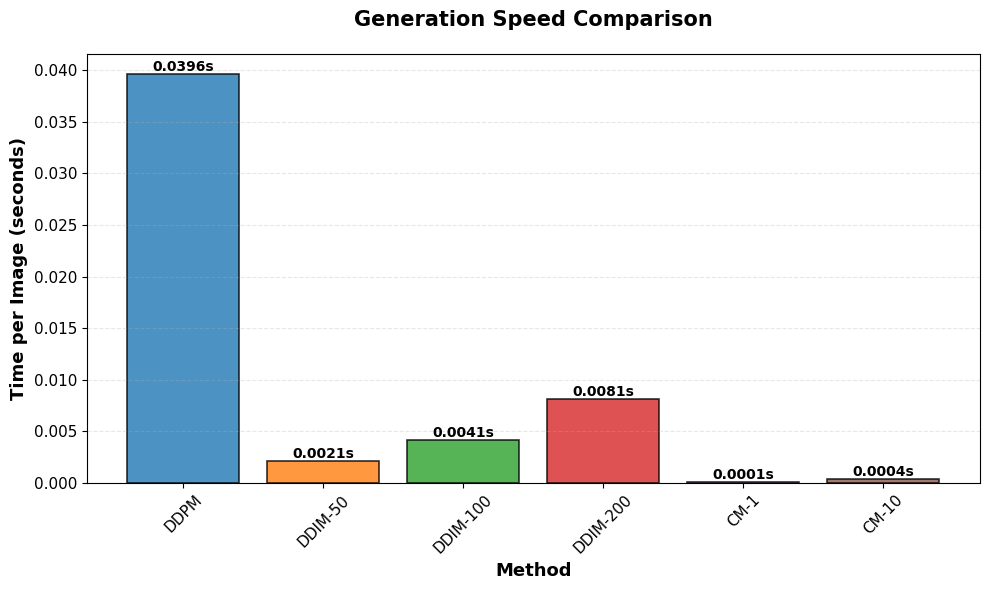

In [81]:
speed_results = []

# DDPM
nfe, total_time, per_img = measure_generation_speed('ddpm', best_model, n_samples=100)
speed_results.append({'Method': 'DDPM', 'NFE': nfe, 'Total (s)': total_time, 'Per Image (s)': per_img})

# DDIM
for steps in [50, 100, 200]:
    nfe, total_time, per_img = measure_generation_speed('ddim', best_model, n_samples=100, num_steps=steps)
    speed_results.append({'Method': f'DDIM-{steps}', 'NFE': nfe, 'Total (s)': total_time, 'Per Image (s)': per_img})

# CM
for steps in [1, 10]:
    nfe, total_time, per_img = measure_generation_speed('cm', cm_model, n_samples=100, num_steps=steps)
    speed_results.append({'Method': f'CM-{steps}', 'NFE': nfe, 'Total (s)': total_time, 'Per Image (s)': per_img})

# DataFrame 생성
df_speed = pd.DataFrame(speed_results)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

methods = df_speed['Method'].tolist()
times = df_speed['Per Image (s)'].tolist()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.bar(methods, times, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax.set_ylabel('Time per Image (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Method', fontsize=13, fontweight='bold')
ax.set_title('Generation Speed Comparison', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# 값 표시
for bar, time in zip(bars, times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{time:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('speed_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

1. CM의 압도적인 속도

* CM-1: DDPM 대비 396배 빠름 (0.0001s/image)
* CM-10: DDPM 대비 99배 빠름 (0.0004s/image)
* 실시간 생성 가능 수준 (1000장 생성 시 0.4초)

2. DDIM 대비 CM-10의 우위

* DDIM-50 대비 5배 빠름
* DDIM-100 대비 10배 빠름
* FID는 유사하면서 속도는 월등

3. 속도-품질 최적점

    * CM-10: NFE=10, FID=42.92

* 품질: DDIM-50 수준
* 속도: DDIM-50 대비 5배

4. CM-1의 한계

* 속도는 가장 빠르지만 (0.0001s) FID 158.75로 품질 저하 심각
* One-step generation의 어려움 확인

### 6.3 정성적 평가
- 클래스별 샘플 이미지 로드

In [104]:
def visualize_class_comparison(class_idx, class_name, n_samples=8):
    from matplotlib.patches import Rectangle
    
    fig, axes = plt.subplots(7, n_samples, figsize=(26, 19))
    
    methods = [
        'Real',
        'DDPM\n(NFE=1000)',
        'DDIM-50\n(NFE=50)',
        'DDIM-100\n(NFE=100)',
        'DDIM-200\n(NFE=200)',
        'CM-1\n(NFE=1)',
        'CM-10\n(NFE=10)'
    ]
    
    dirs = [
        f'images/real/class_{class_idx}_{class_name}',
        f'images/ddpm/class_{class_idx}_{class_name}',
        f'images/ddim_50/class_{class_idx}_{class_name}',
        f'images/ddim_100/class_{class_idx}_{class_name}',
        f'images/ddim_200/class_{class_idx}_{class_name}',
        f'images/cm_1/class_{class_idx}_{class_name}',
        f'images/cm_10/class_{class_idx}_{class_name}'
    ]
    
    for row in range(7):
        for col in range(n_samples):
            img_path = f"{dirs[row]}/img_{col:04d}.png"
            if os.path.exists(img_path):
                img = PILImage.open(img_path)
                axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
    
    for row, method in enumerate(methods):
        fig.text(0.02, 0.88 - row*0.127, method, 
                fontsize=14, fontweight='bold', ha='left', va='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    fig.suptitle(f'Class {class_idx}: {class_name}', fontsize=20, fontweight='bold', y=0.98)
    plt.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.01)
    plt.savefig(f'results/class_{class_idx}_{class_name}_comparison.png', dpi=150)
    plt.close()

import shutil
shutil.rmtree('results', ignore_errors=True)
os.makedirs('results', exist_ok=True)

for class_idx in range(NUM_CLASSES):
    visualize_class_comparison(class_idx, class_names[class_idx])

#### 6.3.1 Class 0: Center

![Class 0 Comparison](results/class_0_Center_comparison.png)

* Real 이미지는 중앙 집중 결함 패턴이 명확하게 나타난다. 
* DDPM은 과도한 노이즈로 패턴이 흐릿하다.
* DDIM-50이 가장 깨끗한 중앙 패턴을 재현하였다. 
* DDIM-100과 200은 샘플링 횟수 증가에 따라 오히려 노이즈가 증가하는 경향을 보였다. * CM-1은 패턴이 불명확하고 극단적인 대비를 보이는 반면, CM-10은 DDIM-50 수준으로 중앙 패턴을 우수하게 재현하였다.

---

#### 6.3.2 Class 1: Donut
![Class 1 Comparison](results/class_1_Donut_comparison.png?v=2)

* Real 이미지는 도넛 형태의 링 패턴을 보인다. 
* DDPM과 DDIM은 링 형태를 유지하나 노이즈가 과다하게 포함되어 있다. 
* CM-1은 링 형태는 인식되나 매우 거친 품질을 보이며, CM-10은 링 패턴 재현이 우수하고 가장 깨끗한 결과를 생성하여 FID 32.06으로 Donut 클래스에서 최고 성능을 달성하였다.

---

#### 6.3.3 Class 2: Edge-Loc
![Class 2 Comparison](results/class_2_Edge-Loc_comparison.png?v=2)

* Real 이미지는 가장자리 국소 결함을 보인다. 
* DDIM-50이 FID 28.60으로 패턴 재현이 가장 우수하며, CM-10도 DDIM 수준의 가장자리 패턴을 안정적으로 재현하였다. 
* DDPM은 전반적으로 노이즈가 많아 가장자리 결함의 위치가 불명확한 경향을 보였다.

---

#### 6.3.4 Class 3: Edge-Ring
![Class 3 Comparison](results/class_3_Edge-Ring_comparison.png?v=2)

* Real 이미지는 가장자리 링 패턴을 나타낸다. 
* DDIM-50이 FID 25.38로 가장 우수한 성능을 보였다. 
* CM-1은 패턴이 붕괴되고 검은 영역이 과다하게 생성되었으며, CM-10은 링 패턴을 유지하나 DDIM 대비 약간 흐린 경향을 보였다.
---

#### 6.3.5 Class 4: Loc
![Class 4 Comparison](results/class_4_Loc_comparison.png?v=2)

* Real 이미지는 국소 결함 패턴을 보인다. 
* DDPM은 과도한 노이즈로 결함 위치가 불명확하며, DDIM-50이 FID 37.83으로 가장 깨끗한 결과를 생성하였다. 
* CM-1은 패턴이 불명확한 반면, CM-10은 국소 결함의 위치를 양호하게 재현하였다.

---

#### 6.3.6 Class 5: Near-full
![Class 5 Comparison](results/class_5_Near-full_comparison.png?v=2)

* Real 이미지는 거의 전체 영역에 결함이 있으며 모서리만 정상인 복잡한 패턴을 보인다. 
* 모든 방법이 FID 58~113 범위로 높은 값을 기록하여 이 클래스의 생성이 매우 어려움을 확인하였다. 
* CM-1은 거의 완전히 흰색 또는 검은색으로 생성 실패를 보였으며, CM-10은 모서리 패턴을 일부 재현하나 불안정한 결과를 나타냈다. 
* 이는 데이터 부족(전체의 0.47%)과 복잡한 패턴의 결합으로 인한 것으로 분석된다.

---

#### 6.3.7 Class 6: Random
![Class 6 Comparison](results/class_6_Random_comparison.png?v=2)

* Real 이미지는 무작위로 분산된 결함을 보인다. 
* DDIM-50이 FID 20.45로 전체 클래스 중 가장 낮은 FID를 기록하였다. 
* CM-1은 패턴이 붕괴되었으나, CM-10은 무작위 분산 패턴을 잘 재현하여 FID 32.69를 달성하였다. 
* 단순한 패턴 특성으로 인해 모든 방법이 상대적으로 우수한 성능을 보였다.

---

#### 6.3.8 Class 7: Scratch
![Class 7 Comparison](results/class_7_Scratch_comparison.png?v=2)
* Real 이미지는 긁힌 선 형태의 결함을 나타낸다. 
* DDPM은 노이즈 과다로 선 형태가 불명확하며, DDIM-50이 선 패턴 재현이 우수하였다.

* CM-1은 극단적인 대비로 패턴이 손실되었으나, CM-10은 긁힌 선 형태를 양호하게 재현하였다.

---

### 6.4 종합 분석
#### 6.4.1 정량적 성능 분석
* 정량적 평가 결과, CM-10은 평균 FID 42.92로 DDIM-50(40.72) 수준의 품질을 달성하면서 NFE=10으로 5배 빠른 생성 속도를 보였다. 특히 DDPM 대비 99배, DDIM-100 대비 10배 빠른 속도로 실시간 데이터 증강 가능성을 확인했다.

#### 6.4.2 클래스별 성능 차이 분석
##### 우수한 성능 (FID < 35)
Random(CM-10: 32.69)과 Donut(CM-10: 32.06) 클래스는 비교적 단순하고 규칙적인 패턴을 가진다. Random은 무작위 점들의 분포, Donut은 명확한 링 형태로 학습이 용이하다. 패턴의 단순성이 생성 모델의 학습을 쉽게 만들었다고 볼 수 있다.

##### 보통 성능 (FID 40~47)
Center(46.97), Edge-Loc(41.90), Edge-Ring(42.37), Loc(44.44), Scratch(44.22) 클래스는 중간 수준의 복잡도를 가진다. 결함의 위치나 형태는 특정되어 있으나 세부 패턴은 다양하다. 대부분의 클래스가 이 범위에 속하여 CM-10의 평균적인 성능을 보여준다.

##### 낮은 성능 (FID > 55)
  Near-full(CM-10: 58.69) 클래스의 낮은 성능은 두 가지 요인으로 보인다. 
* 첫째, 데이터 부족 문제이다. WM-811K 데이터셋에서 Near-full 클래스는 전체의 약 0.47%에 불과하여 학습 샘플이 매우 적다. 일반적으로 생성 모델은 충분한 학습 데이터가 있어야 해당 분포를 정확히 학습할 수 있는데, Near-full은 이 조건을 충족하지 못한 것 같다.

* 둘째, 패턴의 복잡성이다. Near-full은 웨이퍼의 거의 전체 영역에 결함이 있고 네 모서리만 정상인 복잡한 형태이다. 이는 결함 영역과 정상 영역의 경계가 불명확하고, 전체 영역에 걸쳐 있어 다른 클래스들(중앙, 가장자리, 국소 등)에 비해 학습 난이도가 높다. 
    * 실제로 정성적 평가에서 CM-1은 Near-full 클래스에서 거의 완전히 흰색 또는 검은색으로 생성하여 패턴을 전혀 학습하지 못한 것을 확인하였다. CM-10은 모서리 패턴을 일부 재현하였으나 여전히 불안정한 결과를 보였다.


#### 6.4.3 CM-1 vs CM-10 비교
* CM-1은 평균 FID 158.75로 실용성이 없는 수준이며, 정성적 평가에서도 대부분의 클래스에서 패턴 붕괴나 극단적인 흑백 대비만을 보였다. 
    * 단 한 번의 denoising step으로 완전한 노이즈에서 실제 이미지를 생성하는 것은 매우 어려웠던것으로 보인다. 
* 반면 CM-10은 10 step을 통해 점진적으로 이미지를 개선하면서 높은 품질을 달성하였다. NFE=10은 DDPM의 1000 step에 비하면 매우 적은 수치이지만, 품질 유지에는 충분한 것으로 나타났다.

## 7. 참고문헌

### 주요 논문

[1] Ho, J., Jain, A., & Abbeel, P. (2020). "Denoising Diffusion Probabilistic Models." *Advances in Neural Information Processing Systems (NeurIPS)*, 33, 6840-6851.

[2] Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021). "Score-Based Generative Modeling through Stochastic Differential Equations." *International Conference on Learning Representations (ICLR)*.

[3] Song, J., Meng, C., & Ermon, S. (2021). "Denoising Diffusion Implicit Models." *International Conference on Learning Representations (ICLR)*.

[4] Karras, T., Aittala, M., Aila, T., & Laine, S. (2022). "Elucidating the Design Space of Diffusion-Based Generative Models." *Advances in Neural Information Processing Systems (NeurIPS)*, 35, 26565-26577.

[5] Song, Y., Dhariwal, P., Chen, M., & Sutskever, I. (2023). "Consistency Models." *International Conference on Machine Learning (ICML)*, 40, 32211-32252.

---

### 데이터셋

[6] WM-811K Wafer Map Dataset. https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map

---

### 참고 자료

[7] thecho7 블로그 - Consistency Models 설명https://thecho7.tistory.com/entry/%EB%85%BC%EB%AC%B8-%EB%A6%AC%EB%B7%B0-Consistency-Models-%EC%84%A4%EB%AA%85

[8] kimjy99 블로그 - Consistency Models 리뷰 https://kimjy99.github.io/%EB%85%BC%EB%AC%B8%EB%A6%AC%EB%B7%B0/consistency-model/

[9] YouTube - Consistency Model 논문 리뷰 https://www.youtube.com/watch?v=LGMZSqxx4Tc

[10] 네이버 블로그 - ODE (Ordinary Differential Equation) 설명https://m.blog.naver.com/sw4r/221916036607